# Lab Exam 1, AI for Communication and Marketing

*Beatrice Camera, 535313*

Customer data, when left unstructured, offers limited strategic value. Raw variables such as income, purchases, or campaign responses do not directly translate into actionable decisions unless they are framed within a coherent analytical structure. The objective of this analysis is therefore to move from isolated observations to an integrated understanding of customer value, behaviour, and communication opportunities.

**Business context.** As a Junior Data Scientist hired by a retail company, the task is to build the analytical framework that the Marketing Department currently lacks. 

The analytical process follows a progressive logic. It begins with a data audit to ensure that the dataset can support reliable conclusions, addressing missing values, inconsistencies, and outliers. It then moves to exploratory analysis, where the goal is to identify the main drivers of total spending and to uncover patterns of value concentration and value leakage across different customer profiles and purchase channels.

These insights are subsequently formalised through a Recency–Frequency–Monetary (RFM) framework, which translates observed behaviours into lifecycle-based customer segments. This step shifts the analysis from description to structure, enabling a consistent classification of customers based on their engagement and economic value.

Finally, unsupervised learning is introduced to complement the RFM approach. While RFM captures *when* and *how much* customers engage, clustering reveals *how* they differ across multiple dimensions simultaneously, including product preferences and channel behaviour. The integration of these perspectives allows for a more nuanced segmentation that supports targeted communication strategies.

The analysis is organised as follows:

- **Section 1, Data Audit & Quality**: validation and cleaning of the dataset  
- **Section 2, Exploratory Data Analysis**: identification of value drivers and hidden patterns  
- **Section 3, RFM Segmentation**: behavioural segmentation based on lifecycle indicators  
- **Section 4, Cluster Analysis**: multidimensional segmentation and comparison with RFM  
- **Section 5, Communication Strategy**: translation of insights into actionable marketing decisions  
- **Section 6, Conclusion**

The overall objective is not only to understand who the customers are, but to determine how different customer states and profiles require distinct communication approaches, in terms of channel, tone, and content.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import warnings
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.patches as mpatches
import textwrap
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

PALETTE_DIV = sns.color_palette('RdBu', 10)
PALETTE_SEQ = sns.color_palette('YlOrRd', 6)

In [2]:
df_raw = pd.read_csv(
    "https://raw.githubusercontent.com/BeatriceCamera/AI4CM_projects/main/marketing_campaign.csv",
    sep=";"
)

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head()

Dataset shape: 2240 rows × 27 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


The dataset contains 2,240 observations and 27 variables. Each row represents a unique customer, with features spanning socio-demographics, product-level spending across six categories, purchase channel activity, and responses to five marketing campaigns. The structure is unusually rich for a marketing dataset: it combines *who* customers are, *what* they buy, *how* they buy, and *whether* they responded to past campaigns, a combination that makes segmentation here actionable rather than merely descriptive.

## 1. Data Audit and Quality

Before performing any transformation or analysis, I need to understand the composition, quality, and reliability of the dataset.

This initial assessment examines the dataset from two angles: structurally (variable types, missing values, and consistency of recorded informatio) and statistically, through targeted outlier detection on the variables most relevant to downstream segmentation. In a marketing context, data integrity is especially consequential: inaccuracies in customer records propagate directly into segmentation quality, value estimation, and campaign effectiveness.

### **1.1    Duplicates**

Duplicate rows are a silent source of bias since they skew the analysis by inflating counts for certain customer profiles and distorting cluster centroids or campaign response rates. I check for full row duplicates and also for duplicate `ID` values (which would indicate the same customer appearing multiple times in the database).

In [3]:
# Full row duplicates 
full_dups = df_raw.duplicated().sum()

# ID-level duplicates (same customer, possibly different rows)
id_dups = df_raw.duplicated(subset='ID').sum()

print(f"Full duplicate rows  : {full_dups}")
print(f"Duplicate customer IDs: {id_dups}")

if full_dups == 0 and id_dups == 0:
    print("\nNo duplicates found. Each row represents a unique customer.")

Full duplicate rows  : 0
Duplicate customer IDs: 0

No duplicates found. Each row represents a unique customer.


### **1.2 Missing Values**

Understanding where values are missing, and whether missingness is isolated or clustered across multiple columns, is critical before deciding how to handle it. Indeed, missing values can bias results or break the algorithm since poor quality data degrades the performance and the analysis. I use `missingno` to get an immediate visual read on the missingness pattern.

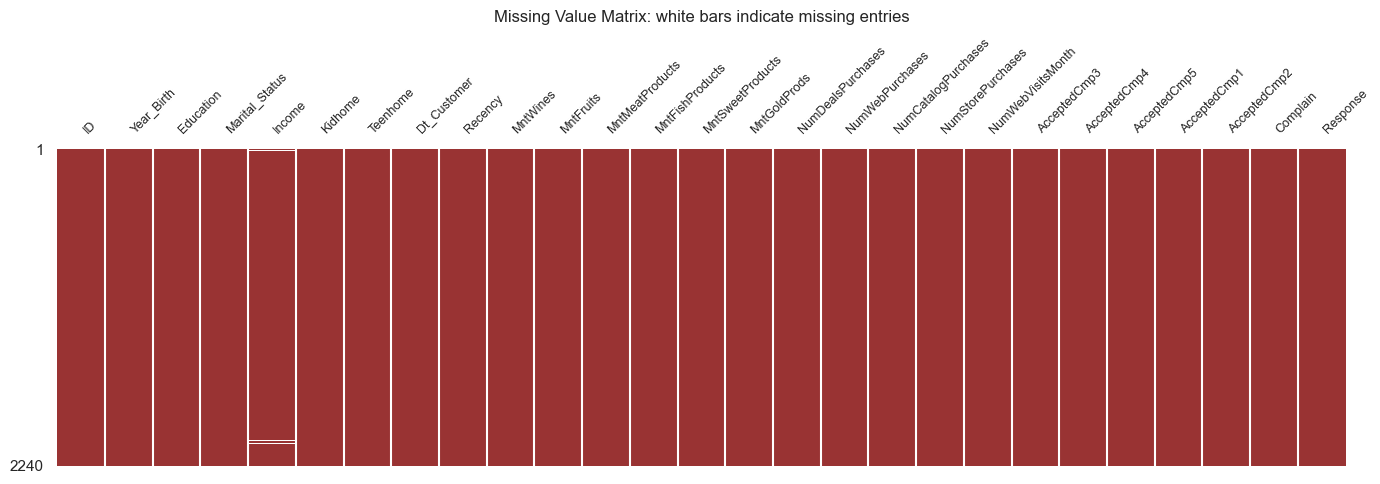

In [4]:
# Missingno matrix: each row is an observation; white = missing
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df_raw, ax=ax, sparkline=False, fontsize=9, color=(0.6, 0.2, 0.2))
ax.set_title("Missing Value Matrix: white bars indicate missing entries", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

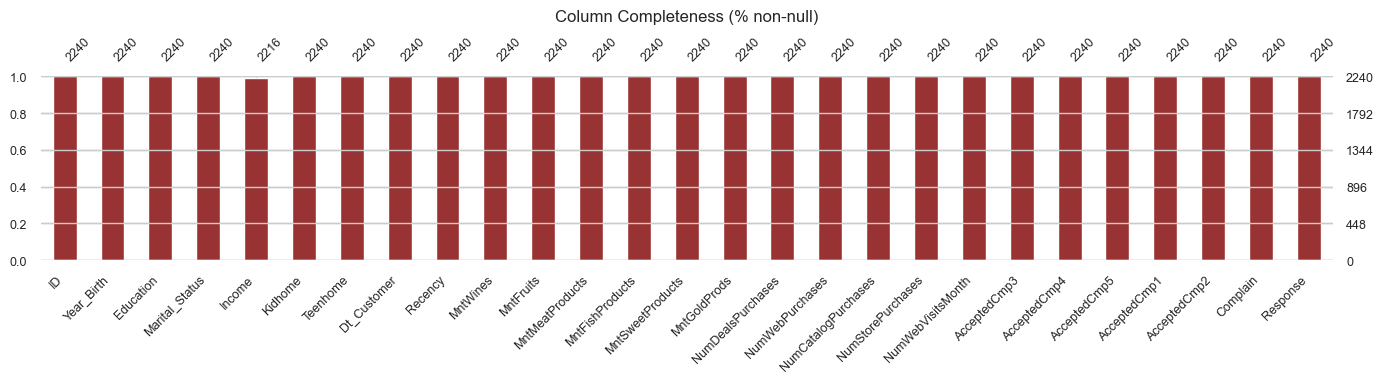

In [5]:
# Missingno bar chart: percentage of completeness per column
fig, ax = plt.subplots(figsize=(14, 4))
msno.bar(df_raw, ax=ax, fontsize=9, color=(0.6, 0.2, 0.2))
ax.set_title("Column Completeness (% non-null)", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

In [6]:
# Focused table: only columns with at least one missing value
missing = df_raw.isna().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)

missing_report = pd.DataFrame({
    'Missing Count': missing_cols,
    'Missing %': (missing_cols / len(df_raw) * 100).round(2)
})
print("Columns with missing values:")
missing_report

Columns with missing values:


,Missing Count,Missing %
Income,24,1.07


The only missing value is the feature `Income`, containing 1.07% missing values (24 observations), which is a relatively low proportion.

Two strategies were considered:

| Strategy | Pros | Cons |
|---------|------|------|
| **Row Deletion** | Ensures data purity; no artificial values introduced | Reduces customer base; may introduce bias if missing values are not randomly distributed |
| **Median Imputation** | Preserves all observations; maintains dataset completeness; robust to skewed distributions | Introduces synthetic values; may slightly smooth the income distribution |

From a data-driven marketing perspective, income is a key variable for understanding customer value and behavior, as it directly influences spending capacity, purchasing patterns, and segmentation outcomes. Removing these observations would reduce the customer base and may introduce bias, especially if missing values are not randomly distributed.

As highlighted in the data-driven approach, data alone is not sufficient: it must be interpreted and transformed into meaningful insights to support strategic decisions. In this context, preserving as much information as possible is essential to maintain the integrity of downstream analyses such as customer segmentation and value estimation.

For this reason, a median imputation strategy is applied:
- The median is robust to skewed distributions, which are typical for income data.
- It allows me to preserve the overall structure of the dataset without being influenced by extreme values.

This choice will be further validated by the EDA that follows, where Income emerges as the single strongest predictor of total spending. A distorted income distribution would directly compromise the quality of downstream segmentation.

In [7]:
df = df_raw.copy()

# Create missing flag before imputation
df['Income_missing_flag'] = df['Income'].isna().astype(int)

missing_before = df['Income'].isna().sum()

# Median imputation
median_income = df['Income'].median()
df['Income'] = df['Income'].fillna(median_income)

missing_after = df['Income'].isna().sum()

print(f"Missing Income values before imputation: {missing_before}")
print(f"Missing Income values after imputation: {missing_after}")
print(f"Median value used for imputation: {median_income:.2f}")

Missing Income values before imputation: 24
Missing Income values after imputation: 0
Median value used for imputation: 51381.50


### **1.3 Data Type Corrections and Feature Engineering**

Two variables require explicit transformation to ensure analytical consistency and business interpretability:

- **`Dt_Customer`**: converted to a `datetime` format to enable the computation of customer tenure (therefore time since enrolment). This variable provides a more meaningful proxy for customer recency and engagement over time.
  
- **`Year_Birth`**: transformed into Age, which is more interpretable from a marketing perspective and facilitates segmentation into meaningful life-stage groups.

Two variables were added:

- **`Total Spend`**: obtained by summing the spending across all product categories (wine, fruit, meat product, fish product, sweet product and gold products).

- **`Total Children`**: derived by summing the total kids with the total teenagers.

In [8]:
# Parse Dt_Customer as datetime 
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Derive Age (reference year = 2015, matching approximate data collection end)
REFERENCE_YEAR = 2015
df['Age'] = REFERENCE_YEAR - df['Year_Birth']

# Derive Tenure in days (days since customer enrolment, relative to latest date in data)
max_date = df['Dt_Customer'].max()
df['Tenure_Days'] = (max_date - df['Dt_Customer']).dt.days

# Derive total spending across all product categories
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpend'] = df[spend_cols].sum(axis=1)

# Derive total number of children at home 
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

print("New features created: Age, Tenure_Days, TotalSpend, TotalChildren")
df[['Year_Birth', 'Age', 'Dt_Customer', 'Tenure_Days', 'TotalSpend', 'TotalChildren']].head()

New features created: Age, Tenure_Days, TotalSpend, TotalChildren


,Year_Birth,Age,Dt_Customer,Tenure_Days,TotalSpend,TotalChildren
0,1957,58,2012-09-04,663,1617,0
1,1954,61,2014-03-08,113,27,2
2,1965,50,2013-08-21,312,776,0
3,1984,31,2014-02-10,139,53,1
4,1981,34,2014-01-19,161,422,1


In addition, the **`Marital_Status`** variable contains semantically equivalent categories recorded with inconsistent labels. These are consolidated to ensure coherence and avoid fragmentation in customer segmentation.

In [9]:
# Inspect Marital_Status raw categories
print("Raw Marital_Status value counts:")
print(df['Marital_Status'].value_counts())

Raw Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


To improve interpretability and ensure meaningful segmentation, categories are consolidated into two analytically relevant groups:

- **Partnered customers (Partner):** Includes individuals living in a couple or shared household:
  - Married
  - Together

- **Non-partnered customers (Alone):** Includes individuals without a partner:
  - Single
  - Divorced
  - Widow
  - Alone

Additionally, the presence of entries such as *“Absurd”* and *“YOLO”* indicates clear data quality issues, likely arising from erroneous or non-serious inputs. Instead of removing these observations, which would also discard potentially valuable behavioral and transactional information, they are reassigned to the *“Alone”* category. This represents the most conservative choice, as their true status cannot be reliably inferred.

This consolidation simplifies the variable while preserving the full customer base and ensuring consistency across observations. From a marketing perspective, a binary distinction between partnered and non-partnered customers is also more actionable, as household composition directly influences purchasing behavior and product relevance (family-oriented vs individual consumption patterns).

In [10]:
marital_map = {
    'Married'  : 'Partner',
    'Together' : 'Partner',
    'Single'   : 'Alone',
    'Divorced' : 'Alone',
    'Widow'    : 'Alone',
    'Alone'    : 'Alone',
    'Absurd'   : 'Alone',
    'YOLO'     : 'Alone'
}

df['Marital_Status_Clean'] = df['Marital_Status'].map(marital_map)

print("Cleaned Marital_Status distribution:")
print(df['Marital_Status_Clean'].value_counts())

Cleaned Marital_Status distribution:
Marital_Status_Clean
Partner    1444
Alone       796
Name: count, dtype: int64


### **1.4 Outlier Detection and Treatment**

Outliers can significantly influence statistical measures and downstream models, particularly in segmentation tasks where cluster centroids are sensitive to extreme values. However, not all extreme values should be treated the same way, and in this dataset, the distinction is especially consequential.

A mechanical approach (like removing everything beyond 1.5×IQR) would treat a customer earning €600,000 and a customer spending €2,500 identically, both flagged as outliers. But the first is almost certainly a data entry error, while the second is exactly the high-value customer a segmentation model should identify and retain. Applying the same rule to both would eliminate the most commercially interesting observations in the dataset.

For this reason, each variable is evaluated individually, combining statistical detection with business plausibility assessment before any action is taken:
1. **Detect** using IQR-based thresholds as a baseline
2. **Evaluate** in terms of real-world plausibility and business meaning
3. **Handle** through the appropriate strategy: removal, retention, or transformation

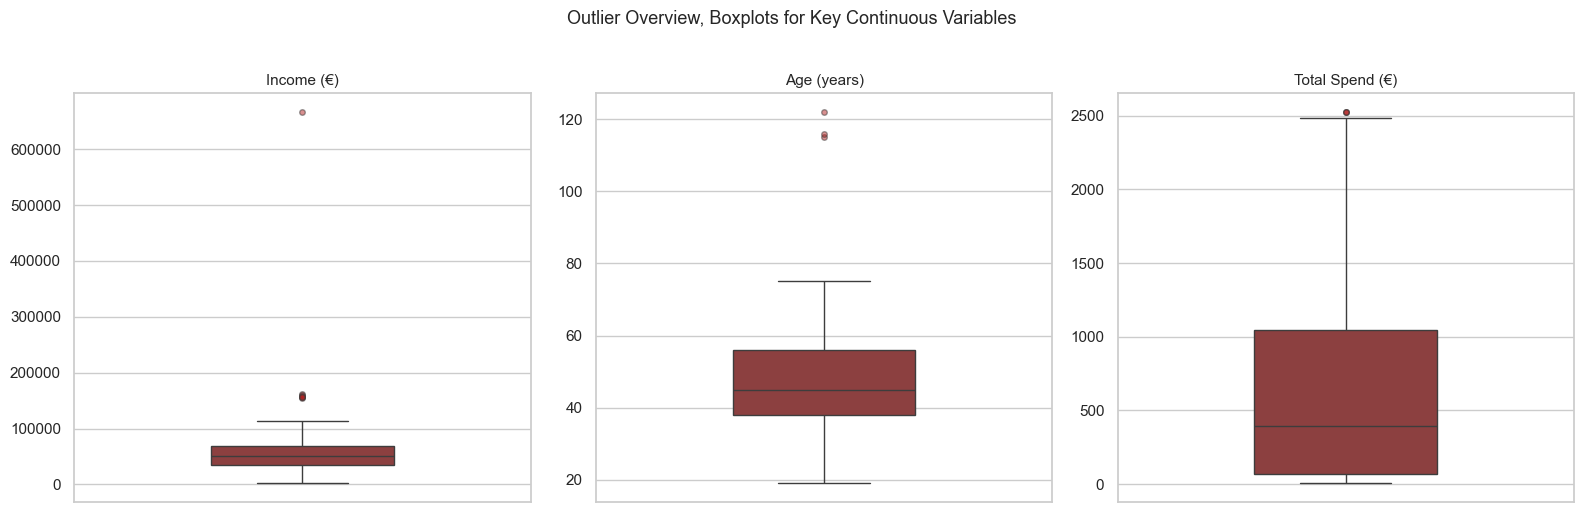

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outlier_vars = [
    ('Income',     'Income (€)',          axes[0]),
    ('Age',        'Age (years)',          axes[1]),
    ('TotalSpend', 'Total Spend (€)',      axes[2]),
]

for col, label, ax in outlier_vars:
    sns.boxplot(y=df[col], ax=ax, color=(0.6, 0.2, 0.2), width=0.4, flierprops=dict(
        marker='o', markerfacecolor='firebrick', markersize=4, alpha=0.5
    ))
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('')

fig.suptitle('Outlier Overview, Boxplots for Key Continuous Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# IQR-based outlier boundaries for each variable 
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                      'Lower Fence': lower, 'Upper Fence': upper,
                      'N Outliers (IQR)': n_out,
                      'Min': series.min(), 'Max': series.max()})

outlier_summary = df[['Income', 'Age', 'TotalSpend']].apply(iqr_bounds).T
outlier_summary

,Q1,Q3,IQR,Lower Fence,Upper Fence,N Outliers (IQR),Min,Max
Income,35538.75,68289.75,32751.00,-13587.75,117416.25,8.00,1730.00,666666.00
Age,38.00,56.00,18.00,11.00,83.00,3.00,19.00,122.00
TotalSpend,68.75,1045.50,976.75,-1396.38,2510.62,3.00,5.00,2525.00


#### 1.4.1 Income Outliers

The distribution of `Income` is right-skewed with a small number of very high earners. I inspect the extreme values before deciding.

In [13]:
income_q99 = df['Income'].quantile(0.99)
extreme_income = df[df['Income'] > income_q99][['ID', 'Income', 'TotalSpend', 'Age']]
print(f"Records above 99th percentile (Income > €{income_q99:,.0f}):")
extreme_income.sort_values('Income', ascending=False)

Records above 99th percentile (Income > €94,438):


,ID,Income,TotalSpend,Age
2233,9432,666666.00,62,38
617,1503,162397.00,107,39
687,1501,160803.00,1717,33
1300,5336,157733.00,59,44
164,8475,157243.00,1608,42
1653,4931,157146.00,1730,38
2132,11181,156924.00,8,66
655,5555,153924.00,6,40
1898,4619,113734.00,277,70
646,4611,105471.00,1724,45


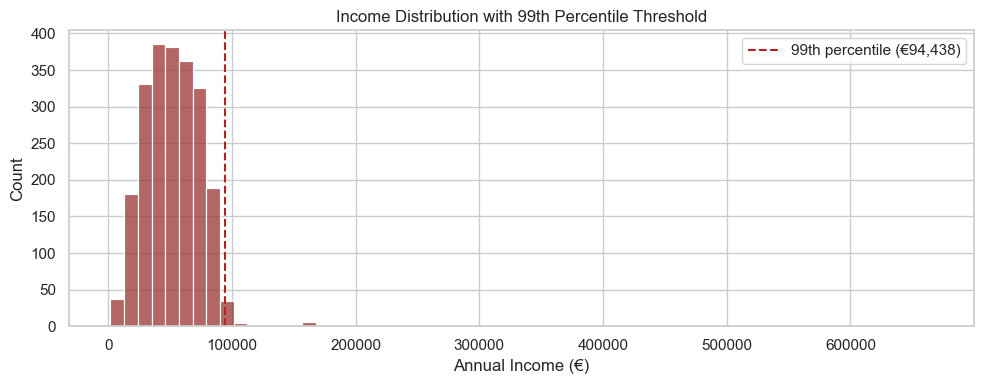

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['Income'], bins=60, ax=ax, color=(0.6, 0.2, 0.2), edgecolor='white')
ax.axvline(income_q99, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'99th percentile (€{income_q99:,.0f})')
ax.set_xlabel('Annual Income (€)')
ax.set_title('Income Distribution with 99th Percentile Threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Decision: Remove extreme values above the 99th percentile**

Outliers in `Income` are identified using the 99th percentile threshold  (€94,438). The distribution above this threshold is examined manually and reveals a bimodal pattern: the large majority of records in this range have incomes between €95,000 and €165,000, which are elevated but plausible for a retail customer base. One record, however, shows an income of €666,666, an order of magnitude above the rest, which is most likely a data entry error (annual salary entered as a different unit, or a transcription mistake).

Rather than treating the tail as uniformly implausible, the decision to apply the 99th percentile cutoff is justified on two grounds. First, it removes the extreme upper tail of the distribution, including the single clearly anomalous observation (€666,666), while affecting less than 1% of the dataset. Second, capping at the 99th percentile would introduce a synthetic value for the true income, which is unknown, removal is cleaner than imputation with an arbitrary ceiling.

The analytical cost is negligible. The risk of retaining a single extreme value that pulls cluster centroids toward an implausible extreme is structurally more damaging than losing fewer than 25 records.

Two alternatives were considered and rejected:
- **Capping at the 99th percentile**: would retain the extreme upper tail of the income distribution, including the clearly anomalous record (€666,666). Although most observations above the threshold are plausible, extreme values can disproportionately influence distance-based analyses and shift cluster centroids toward atypical regions of the feature space.
- **Keeping all values**: would retain the single genuinely anomalous record (€666,666) alongside a small number of high but plausible values. The risk is asymmetric: one extreme data point exerts disproportionate influence on cluster centroids relative to its negligible count.

Removal is therefore the cleanest option: the information loss is negligible (< 1% of records) and the analytical benefit is significant.

In [15]:
rows_before = len(df)
df = df[df['Income'] <= income_q99].copy()
print(f"Rows removed (extreme Income): {rows_before - len(df)}")
print(f"Remaining rows: {len(df)}")

Rows removed (extreme Income): 23
Remaining rows: 2217


#### 1.4.2 Age Outliers

I check for implausible ages derived from `Year_Birth`. Customers born before 1930 (age > 85 in 2015) are suspect.

In [16]:
extreme_age = (
    df[df['Age'] > 85]
    [['ID', 'Year_Birth', 'Age', 'Income', 'TotalSpend']]
    .sort_values(by='Age', ascending=False)
)

print("Records with Age > 85 (Year_Birth < 1930):")
display(extreme_age)

age_min = df['Age'].min()
age_max = df['Age'].max()

print(f"Age range in dataset: {age_min} – {age_max}")

Records with Age > 85 (Year_Birth < 1930):


,ID,Year_Birth,Age,Income,TotalSpend
239,11004,1893,122,60182.00,22
339,1150,1899,116,83532.00,1853
192,7829,1900,115,36640.00,65


Age range in dataset: 19 – 122


In [17]:
rows_before = len(df)
df = df[df['Year_Birth'] >= 1900].copy()
print(f"Rows removed (Year_Birth < 1900): {rows_before - len(df)}")
print(f"Remaining rows: {len(df)}")

Rows removed (Year_Birth < 1900): 2
Remaining rows: 2215


**Decision: Remove only biologically implausible values**

Outliers in `Age` are evaluated on plausibility grounds rather than statistical thresholds. A mechanical IQR-based rule would flag customers in their late 70s and 80s as outliers, but these are entirely plausible retail customers, and removing them would introduce a systematic bias against older cohorts in the segmentation.

The primary removal criterion here is biological implausibility: `Year_Birth < 1900` (implying an age above 115 years) is highly unlikely and treated as a data quality issue. Moderately extreme values in the 85–100 range are retained, unusual, but not impossible, and their behavioral data remains analytically valid.

Two alternatives were considered and rejected:
- **IQR-based removal**: would eliminate legitimate elderly customers, introducing age bias into all downstream analyses and artificially compressing the age distribution.
- **Capping at a fixed threshold (like 80)**: arbitrary and unjustified, there is no business reason to exclude an 82-year-old customer who genuinely shops at this retailer.

#### 1.4.3 Total Spend Outliers

`TotalSpend` is the sum of all product category spending. High values here, unlike high `Income`, are not necessarily errors, they represent genuinely high-value customers. I visualise the distribution before deciding.

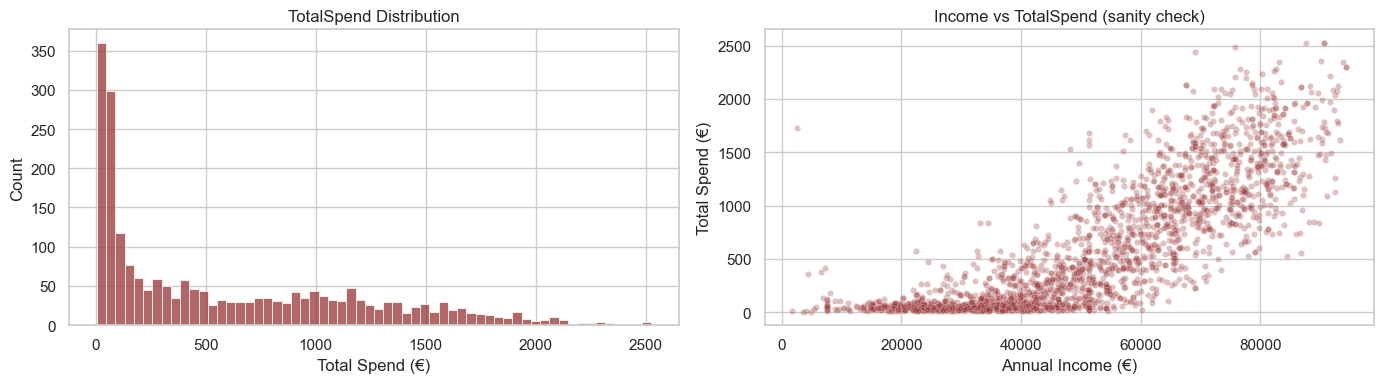

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['TotalSpend'], bins=60, ax=axes[0], color=(0.6, 0.2, 0.2), edgecolor='white')
axes[0].set_title('TotalSpend Distribution')
axes[0].set_xlabel('Total Spend (€)')

sns.scatterplot(data=df, x='Income', y='TotalSpend', ax=axes[1],
                alpha=0.3, s=20, color=(0.6, 0.2, 0.2))
axes[1].set_title('Income vs TotalSpend (sanity check)')
axes[1].set_xlabel('Annual Income (€)')
axes[1].set_ylabel('Total Spend (€)')

plt.tight_layout()
plt.show()

**Decision: Retain all values, no capping or removal**

Although statistical methods flag extreme values in `TotalSpend`, these observations lie in the upper tail of the distribution but remain economically plausible. The scatter plot confirms a coherent, positive relationship between `Income` and `TotalSpend`: high-spending customers are proportionally high-income, which is economically consistent and expected.

In a marketing setting, these customers are precisely the group we want to understand and retain. They represent a disproportionate share of the value generated by the business, so removing or compressing them would weaken the very distinction the segmentation is meant to capture.

Two alternatives were considered and rejected:
- **Capping at the 99th percentile**: would artificially compress the spend distribution and merge the highest-value customers with mid-tier ones, destroying exactly the differentiation that makes premium segmentation possible.
- **IQR-based removal**: would eliminate legitimate high-value customers, reducing both the quality of the segmentation and the actionability of the resulting communication strategy.

### **1.5 Cleaned Dataset Summary**

The table below provides a before/after comparison of every cleaning decision made in this phase. The cleaned dataset is then exported as the single source of truth for the EDA and segmentation that follow. Each decision was made with the downstream objective in mind: preserve analytically valuable observations, remove only what is genuinely erroneous, and engineer features that make customer behavior directly interpretable for segmentation.

In [19]:
# Compute key metrics for summary
rows_before = df_raw.shape[0]
rows_after = df.shape[0]

income_missing_before = df_raw['Income'].isna().sum()
income_missing_after = df['Income'].isna().sum()

duplicates_before = df_raw.duplicated().sum()
duplicates_after = df.duplicated().sum()

marital_before = df_raw['Marital_Status'].nunique()
marital_after = df['Marital_Status_Clean'].nunique()

rows_removed_income = rows_before - df[df['Income'] <= df['Income'].quantile(0.99)].shape[0]
rows_removed_age = (df_raw['Year_Birth'] < 1900).sum()

# Summary table
summary = pd.DataFrame({
    'Metric': [
        'Total rows',
        'Columns',
        'Missing values (Income)',
        'Duplicate rows',
        'Extreme Income (>P99)',
        'Implausible Age (Year_Birth < 1900)',
        'Marital categories',
        'Engineered features'
    ],
    'Before cleaning': [
        rows_before,
        df_raw.shape[1],
        income_missing_before,
        duplicates_before,
        'Present',
        rows_removed_age,
        marital_before,
        'None'
    ],
    'After cleaning': [
        rows_after,
        df.shape[1],
        income_missing_after,
        duplicates_after,
        f"Removed: {rows_removed_income}",
        'Removed',
        marital_after,
        'Age, Tenure_Days, TotalSpend, TotalChildren'
    ]
})

summary.set_index('Metric')

,Before cleaning,After cleaning
Metric,,
Total rows,2240,2215
Columns,27,33
Missing values (Income),24,0
Duplicate rows,0,0
Extreme Income (>P99),Present,Removed: 48
Implausible Age (Year_Birth < 1900),2,Removed
Marital categories,8,2
Engineered features,None,"Age, Tenure_Days, TotalSpend, TotalChildren"


## 2. Exploratory Data Analysis (EDA)

The cleaning phase established a reliable analytical foundation: Income missingness was addressed via median imputation, preserving all 24 affected records in the dataset. Subsequent removal of implausible outliers (23 extreme income values and 2 biologically implausible birth years) reduced the final analytical dataset to 2,215 customers. Four new features were engineered: `Age`, `Tenure_Days`, `TotalSpend`, `TotalChildren`, that serve as the primary analytical dimensions throughout this section.

With data integrity confirmed, the EDA shifts the question from *'is this data trustworthy?'* to *'what does this data reveal?'*. Four lines of inquiry structure the analysis:
1. **Who spends the most** and what demographic profile drives customer value?
2. **Where do customers buy** and does channel preference vary meaningfully by segment?
3. **Which high-value customers are going silent** and have past campaigns reached them?
4. **What conversion friction exists online** and how can it be resolved?

In [20]:
# Income tertiles -> Low / Mid / High
df['Income_Segment'] = pd.qcut(
    df['Income'], q=3,
    labels=['Low Income', 'Mid Income', 'High Income']
)

# Age brackets aligned with life stages
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 35, 50, 65, 120],
    labels=['18–35', '36–50', '51–65', '65+']
)

# Has children vs child-free
df['Has_Children'] = df['TotalChildren'].apply(lambda x: 'Child-Free' if x == 0 else 'Has Children')

# Channel columns
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumDealsPurchases']
channel_labels = ['Web', 'Catalog', 'Store', 'Deals']

# Product spending columns
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spend_labels = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

print("Segmentation helpers created.")

Segmentation helpers created.


### **2.1 Socio-Demographic Drivers of Total Spending**

Understanding *who* spends the most is the foundation of any segmentation strategy. I examine four key demographic dimensions: Income, Age, Family Composition, and Education, analysing both their individual relationships with total spending and the behavioral nuance each one adds beyond the others.

I open with a correlation heatmap to get a bird's-eye view of the full variable space, then drill into each driver individually with targeted visualisations.

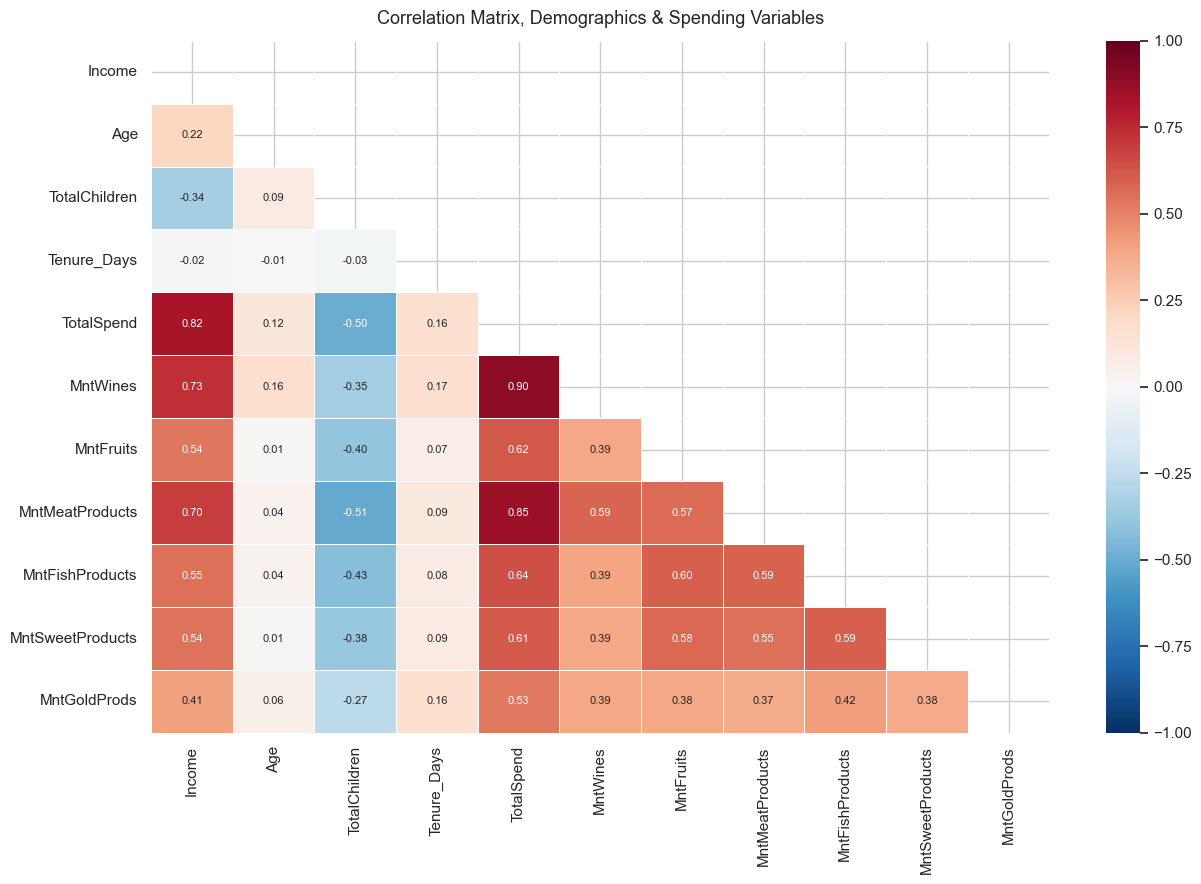

In [21]:
# Correlation heatmap: demographics × spending
corr_cols = ['Income', 'Age', 'TotalChildren', 'Tenure_Days',
             'TotalSpend'] + spend_cols

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Matrix, Demographics & Spending Variables', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

As expected, Income shows the strongest positive correlation with `TotalSpend`, confirming its role as the primary economic driver of customer value. In contrast, `TotalChildren` is negatively correlated with spending, suggesting structural differences in consumption patterns across household types. Age and Tenure exhibit only weak linear relationships with spending. However, low correlation does not necessarily imply low importance, as some effects may emerge only within specific customer groups or through non-linear patterns. 

For this reason, the heatmap is used as a starting point, while deeper analysis is conducted through targeted visualizations for each variable.

The sections below drill into each driver individually, starting with Income, the strongest signal, and moving through Age, household composition, and Education, each of which adds a distinct layer of behavioral nuance that income alone cannot capture.

#### 2.1.1 Income and Total Spending

Does spending scale proportionally with income, or does the relationship plateau at higher earnings? If income is truly the primary lever, we should see a strong, near-linear gradient, and the gap between income tiers should be large enough to justify income-differentiated communication strategies.

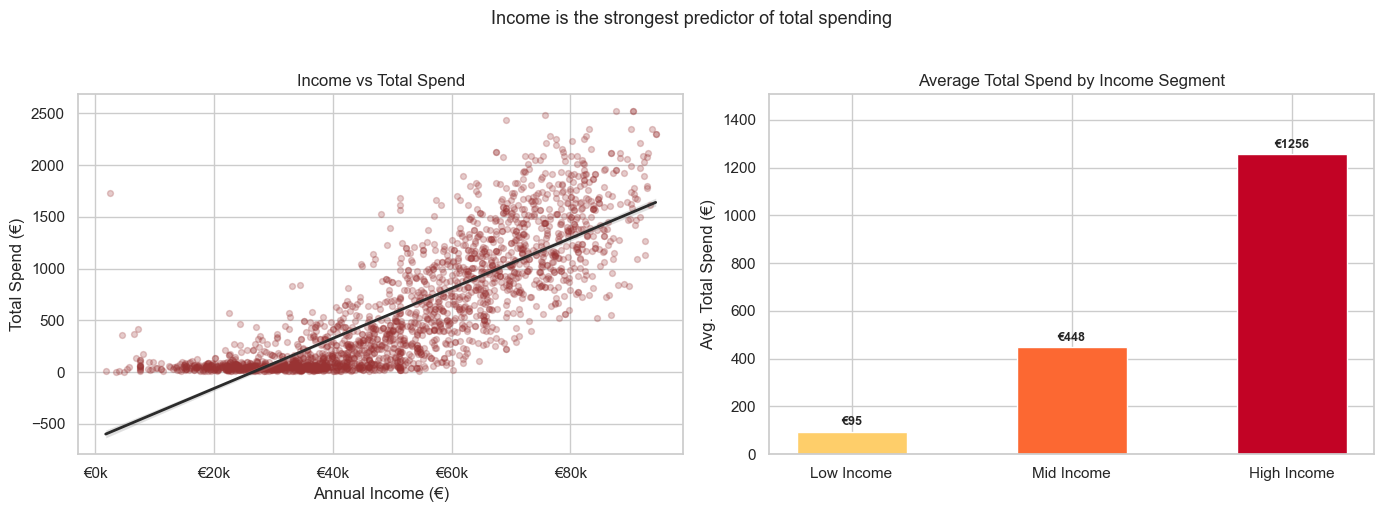

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression line
sns.regplot(
    data=df, x='Income', y='TotalSpend',
    scatter_kws={'alpha': 0.25, 's': 18, 'color': (0.6, 0.2, 0.2)},
    line_kws={'color': (0.17, 0.17, 0.17), 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Income vs Total Spend')
axes[0].set_xlabel('Annual Income (€)')
axes[0].set_ylabel('Total Spend (€)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

# Mean TotalSpend by Income segment
seg_spend = df.groupby('Income_Segment', observed=True)['TotalSpend'].mean().reset_index()
bars = axes[1].bar(
    seg_spend['Income_Segment'], seg_spend['TotalSpend'],
    color=[PALETTE_SEQ[1], PALETTE_SEQ[3], PALETTE_SEQ[5]], edgecolor='white', width=0.5
)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'€{bar.get_height():.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_title('Average Total Spend by Income Segment')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg. Total Spend (€)')
axes[1].set_ylim(0, seg_spend['TotalSpend'].max() * 1.2)

fig.suptitle('Income is the strongest predictor of total spending', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Income is the strongest driver of spending, but its effect is not uniform across customers. Average spend increases by approximately **3–4×**. Taken end-to-end, high-income customers spend over **13×** more than low-income ones (€1,256 vs €95).

At higher income levels, however, dispersion widens, not all high-income customers behave uniformly. Some spend at the expected premium level; others remain relatively disengaged. This signals that income alone is necessary but not sufficient for targeting: within the high-income tier, further behavioral differentiation is needed to separate genuinely high-value customers from low-engagement ones.

This heterogeneity within the high-income tier is one of the analytical justifications for the clustering approach in Section 4: income alone  cannot separate an active high-value customer from a disengaged one at the same income level.

#### 2.1.2 Age and Total Spending

Does spending grow linearly with age, or are there specific life stages where customers are disproportionately valuable? The answer directly shapes how marketing budget should be allocated across generational cohorts.

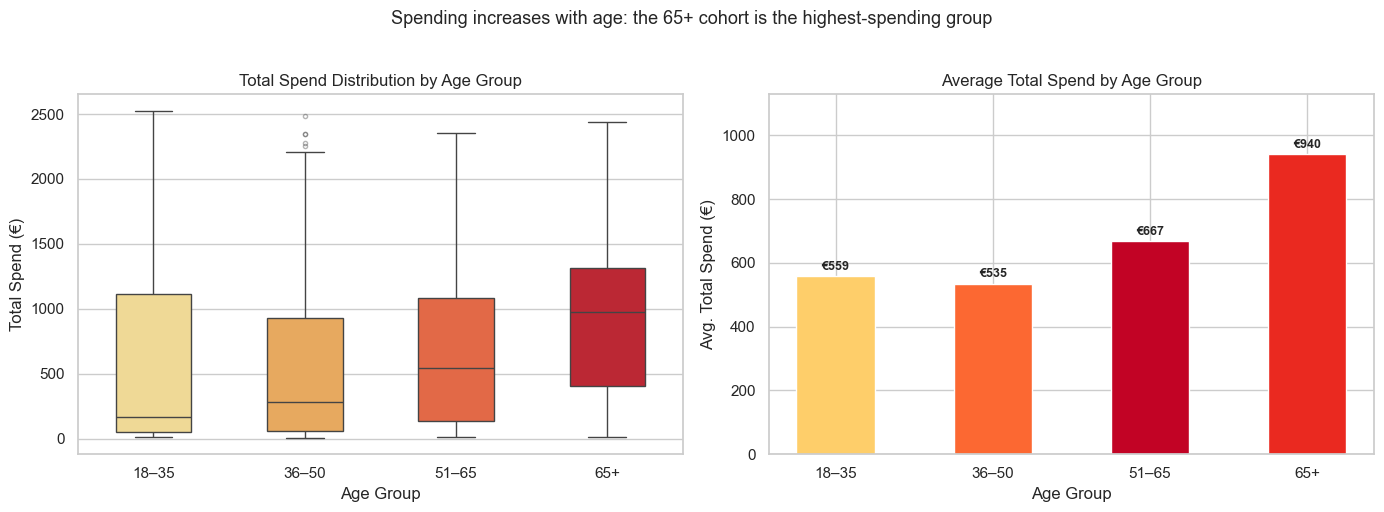

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: TotalSpend by Age Group
sns.boxplot(
    data=df, x='Age_Group', y='TotalSpend',
    palette='YlOrRd', order=['18–35', '36–50', '51–65', '65+'],
    width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
axes[0].set_title('Total Spend Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Spend (€)')

# Mean spend by age group (bar)
age_spend = (
    df.groupby('Age_Group', observed=True)['TotalSpend']
    .mean().reset_index()
    .sort_values('Age_Group')
)
colors_age = [PALETTE_SEQ[1], PALETTE_SEQ[3], PALETTE_SEQ[5], PALETTE_SEQ[4]]
bars = axes[1].bar(
    age_spend['Age_Group'], age_spend['TotalSpend'],
    color=colors_age, edgecolor='white', width=0.5
)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'€{bar.get_height():.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_title('Average Total Spend by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Avg. Total Spend (€)')
axes[1].set_ylim(0, age_spend['TotalSpend'].max() * 1.2)

fig.suptitle('Spending increases with age: the 65+ cohort is the highest-spending group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Spending varies across age groups, but the relationship is not linear. Customers aged 36–50 spend slightly less on average (€535) than the 18–35 cohort (€559). Spending then rises substantially among older customers, reaching €667 for the 51–65 group (+25% vs 36–50) and €940 for customers aged 65 and above (+69% vs 18–35 and +76% vs 36–50).

The boxplots show considerable variability within each age group, suggesting that age alone is not sufficient to explain customer value. Nevertheless, customers aged 51+ consistently generate higher spending levels and represent the retailer's most valuable age segment.

The temporary dip observed in the 36–50 cohort suggests that additional factors beyond age influence spending behavior, motivating a deeper analysis of household composition and other demographic characteristics.

#### 2.1.3 Family Composition and Total Spending

Conventional wisdom might suggest that households with children spend more, more people, more needs. Does the data support this? Or do children represent a *budget constraint* that redirects spending away from the categories this retailer sells?

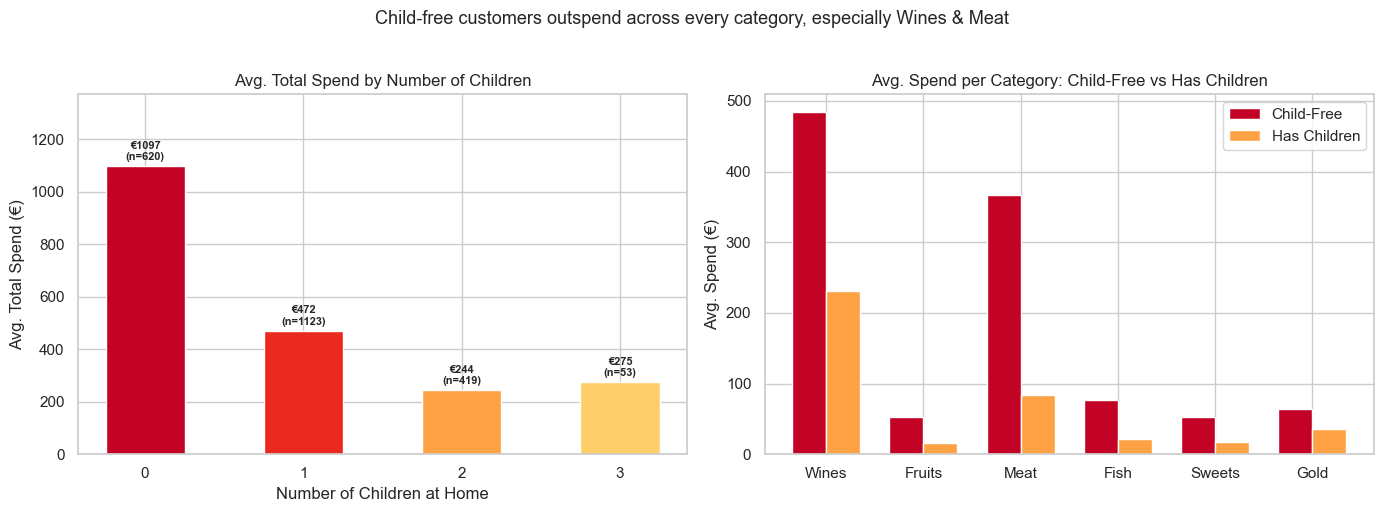

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean spend by number of children
children_spend = (
    df.groupby('TotalChildren', observed=True)['TotalSpend']
    .agg(['mean', 'count']).reset_index()
    .rename(columns={'mean': 'AvgSpend', 'count': 'N'})
)
bars = axes[0].bar(
    children_spend['TotalChildren'].astype(str),
    children_spend['AvgSpend'],
    color=[PALETTE_SEQ[5], PALETTE_SEQ[4], PALETTE_SEQ[2], PALETTE_SEQ[1]],
    edgecolor='white', width=0.5
)
for bar, n in zip(bars, children_spend['N']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'€{bar.get_height():.0f}\n(n={n})',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )
axes[0].set_title('Avg. Total Spend by Number of Children')
axes[0].set_xlabel('Number of Children at Home')
axes[0].set_ylabel('Avg. Total Spend (€)')
axes[0].set_ylim(0, children_spend['AvgSpend'].max() * 1.25)

# Spend by category × Has Children
cat_children = df.groupby('Has_Children', observed=True)[spend_cols].mean()
cat_children.columns = spend_labels
cat_children = cat_children.T.reset_index()
cat_children.columns = ['Category', 'Child-Free', 'Has Children']

x = np.arange(len(cat_children))
w = 0.35
axes[1].bar(x - w/2, cat_children['Child-Free'],   width=w, label='Child-Free',   color=PALETTE_SEQ[5], edgecolor='white')
axes[1].bar(x + w/2, cat_children['Has Children'], width=w, label='Has Children', color=PALETTE_SEQ[2], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_children['Category'])
axes[1].set_title('Avg. Spend per Category: Child-Free vs Has Children')
axes[1].set_ylabel('Avg. Spend (€)')
axes[1].legend()

fig.suptitle('Child-free customers outspend across every category, especially Wines & Meat',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The data contradicts the intuitive expectation: child-free customers consistently spend more, and the gap widens with each additional child. A customer with no children spends roughly **2–3× more** than one with two children at home. One possible explanation is that households with children allocate a larger share of their budget to expenses that are not captured in this retail dataset, reducing the amount available for discretionary purchases.

The category breakdown makes this concrete: the largest gaps appear in Wines and Meat, premium, adult-oriented products. Child-free customers are not just spending more in aggregate; they are spending on exactly the categories where margin is highest.

#### 2.1.4 Education and Total Spending

Income and education are correlated, but does education add explanatory power *beyond* income? If PhD and Master's holders spend more even after controlling for earning capacity, it suggests a preference effect: higher education is associated with different product choices, not just greater purchasing power.

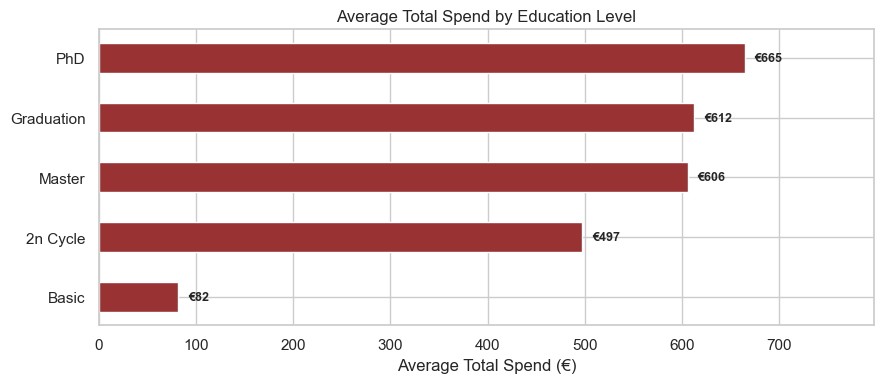

In [25]:
edu_spend = (
    df.groupby('Education', observed=True)['TotalSpend']
    .mean().sort_values(ascending=True).reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    edu_spend['Education'], edu_spend['TotalSpend'],
    color=(0.6, 0.2, 0.2), edgecolor='white', height=0.5
)
for bar in bars:
    ax.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
        f'€{bar.get_width():.0f}',
        va='center', fontsize=9, fontweight='bold'
    )
ax.set_xlabel('Average Total Spend (€)')
ax.set_title('Average Total Spend by Education Level', fontsize=12)
ax.set_xlim(0, edu_spend['TotalSpend'].max() * 1.2)
plt.tight_layout()
plt.show()

Spending generally increases with education level. Customers with a Master's degree, Graduation degree, or PhD spend around €600–€665 on average, compared with €497 for 2nd Cycle customers and just €82 for the Basic segment. Part of this pattern is likely explained by the relationship between education and income. However, the relatively similar spending levels observed across the highest education groups suggest that education may also capture differences in preferences and purchasing behavior beyond income alone.

From a marketing perspective, these customers may respond better to product quality, expertise, and curated recommendations than to purely price-driven promotions.

### **2.2 Purchase Channel Analysis**

Customers do not all shop in the same way. Understanding *where* purchases happen, and which customer profiles prefer which channels, is essential for designing effective multi-channel communication strategies. A promotion delivered through the wrong channel is a wasted touchpoint.

The dataset captures four purchase channels: 
1. Web, 
2. Catalog, 
3. Store, 
4. Deals (discount-driven purchases).

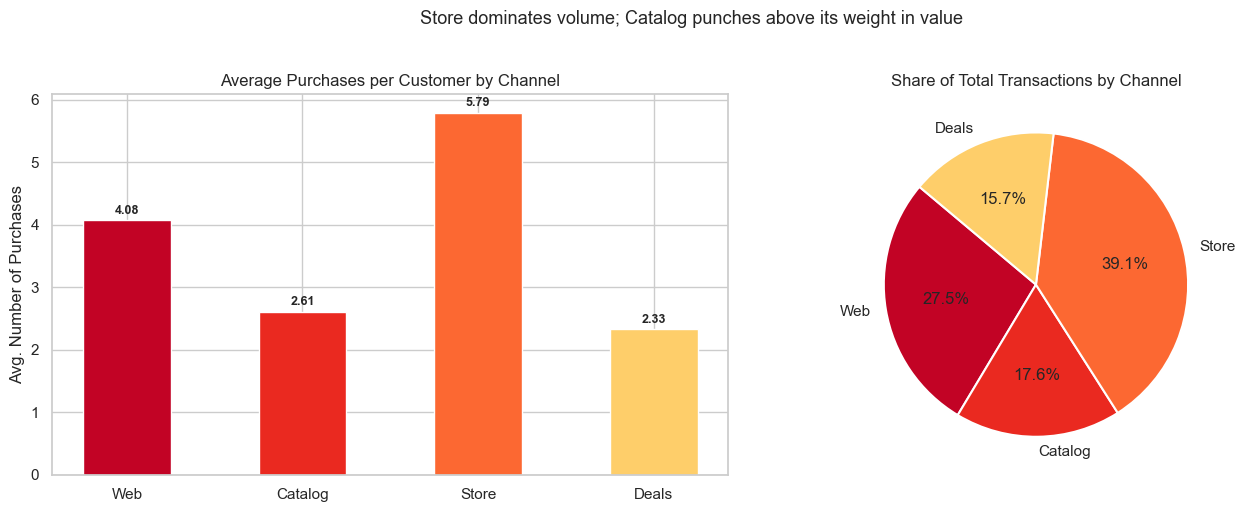

In [26]:
# Overall channel volume 
channel_means = df[channel_cols].mean()
channel_totals = df[channel_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average purchases per channel
colors_ch = [PALETTE_SEQ[5], PALETTE_SEQ[4], PALETTE_SEQ[3], PALETTE_SEQ[1]]
bars = axes[0].bar(channel_labels, channel_means, color=colors_ch, edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[0].set_title('Average Purchases per Customer by Channel')
axes[0].set_ylabel('Avg. Number of Purchases')

# Share of total transactions
share = channel_totals / channel_totals.sum() * 100
wedge_colors = [PALETTE_SEQ[5], PALETTE_SEQ[4], PALETTE_SEQ[3], PALETTE_SEQ[1]]
axes[1].pie(
    share, labels=channel_labels, autopct='%1.1f%%',
    colors=wedge_colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Share of Total Transactions by Channel')

fig.suptitle('Store dominates volume; Catalog punches above its weight in value',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The Store channel dominates customer activity, accounting for 39.1% of all transactions and the highest average number of purchases per customer. This confirms that physical retail remains the company's main interaction channel.

Web is the second most important channel, representing more than one quarter of all transactions, while Catalog and Deals are used less frequently.

The results suggest that customers interact with the brand through multiple channels rather than relying on a single touchpoint. This makes channel preference an important variable for segmentation and campaign design, as different customer groups may respond to different communication channels.

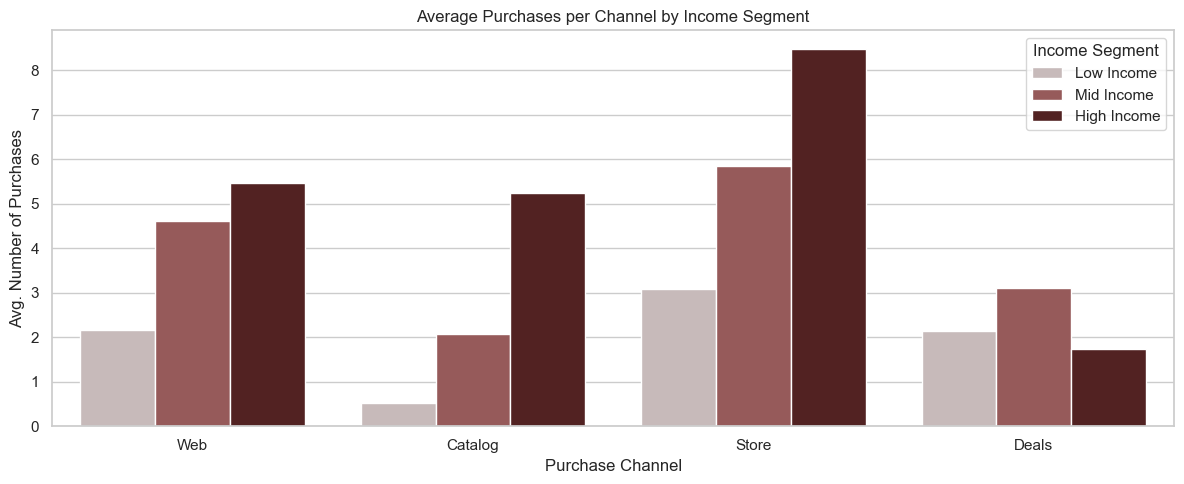

In [27]:
# Channel usage by income segment 
channel_income = (
    df.groupby('Income_Segment', observed=True)[channel_cols]
    .mean().reset_index()
)
channel_income.columns = ['Income_Segment'] + channel_labels
channel_income_melt = channel_income.melt(
    id_vars='Income_Segment', var_name='Channel', value_name='Avg Purchases'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=channel_income_melt,
    x='Channel', y='Avg Purchases', hue='Income_Segment',
    palette=['#c9b8b8', '#a05050', '#5a1a1a'],
    ax=ax
)
ax.set_title('Average Purchases per Channel by Income Segment', fontsize=12)
ax.set_xlabel('Purchase Channel')
ax.set_ylabel('Avg. Number of Purchases')
ax.legend(title='Income Segment')
plt.tight_layout()
plt.show()

Channel usage varies substantially across income segments. As income increases, customers purchase more frequently across all channels, with the strongest growth observed in Catalog and Store purchases. High-income customers make more than twice as many Catalog purchases as mid-income customers and nearly ten times as many as low-income customers.

Deals follow a different pattern. While low- and mid-income customers make frequent use of promotional purchases, Deal usage declines among high-income customers, suggesting lower reliance on discounts.

These results indicate that communication channels should be aligned with customer value. Higher-value customers are more engaged through Catalog, Store, and Web interactions, whereas price-based promotions are likely to be more relevant for lower-value segments.

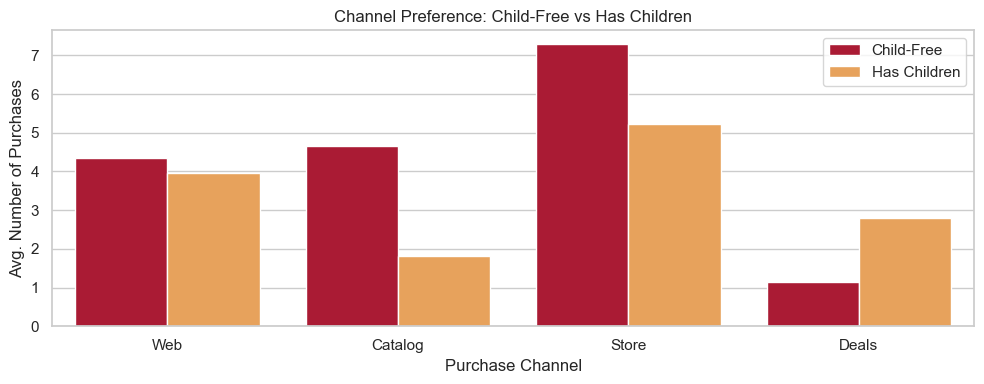

In [28]:
# Channel usage: child-free vs has children 
channel_children = (
    df.groupby('Has_Children', observed=True)[channel_cols]
    .mean().reset_index()
)
channel_children.columns = ['Has_Children'] + channel_labels
channel_children_melt = channel_children.melt(
    id_vars='Has_Children', var_name='Channel', value_name='Avg Purchases'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=channel_children_melt,
    x='Channel', y='Avg Purchases', hue='Has_Children',
    palette=[PALETTE_SEQ[5], PALETTE_SEQ[2]],
    ax=ax
)
ax.set_title('Channel Preference: Child-Free vs Has Children', fontsize=12)
ax.set_ylabel('Avg. Number of Purchases')
ax.set_xlabel('Purchase Channel')
ax.legend(title='')
plt.tight_layout()
plt.show()

Household composition further differentiates channel behavior. Customers with children make more than twice as many Deal purchases as child-free customers (2.8 vs 1.1 on average), suggesting a stronger reliance on promotions. In contrast, child-free customers are substantially more active in Catalog and Store channels, with Catalog purchases occurring at more than twice the rate observed among customers with children.

These results indicate that channel preference is influenced not only by income but also by household structure. While families appear more promotion-oriented, child-free customers engage more heavily with channels associated with higher overall spending levels.

#### 2.2.1 Channel Breadth and Customer Value

Beyond *which* channels customers use, there is a more fundamental question: does using *more* channels make a customer more valuable, or do high-value customers simply gravitate towards more channels naturally?

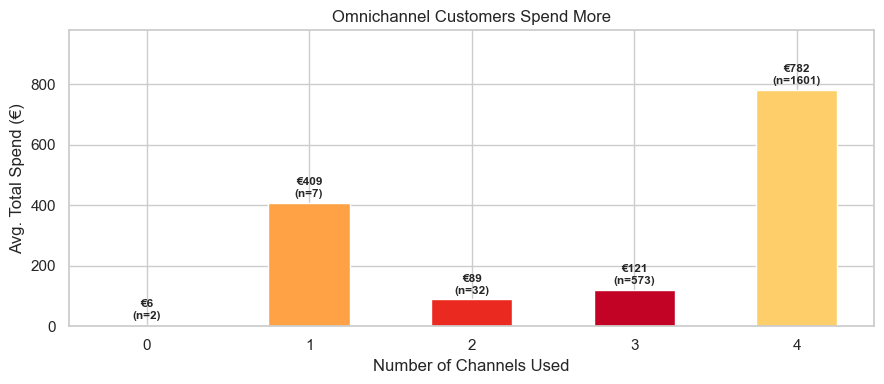

In [29]:
# How many channels does each customer actively use? (> 0 purchases)
df['Channels_Used'] = (df[channel_cols] > 0).sum(axis=1)

breadth_spend = (
    df.groupby('Channels_Used')['TotalSpend']
    .agg(['mean', 'count']).reset_index()
    .rename(columns={'mean': 'AvgSpend', 'count': 'N'})
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    breadth_spend['Channels_Used'].astype(str),
    breadth_spend['AvgSpend'],
    color=[PALETTE_SEQ[1], PALETTE_SEQ[2], PALETTE_SEQ[4], PALETTE_SEQ[5]],
    edgecolor='white', width=0.5
)
for bar, n in zip(bars, breadth_spend['N']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 12,
        f'€{bar.get_height():.0f}\n(n={n})',
        ha='center', va='bottom', fontsize=8.5, fontweight='bold'
    )
ax.set_title('Omnichannel Customers Spend More', fontsize=12)
ax.set_xlabel('Number of Channels Used')
ax.set_ylabel('Avg. Total Spend (€)')
ax.set_ylim(0, breadth_spend['AvgSpend'].max() * 1.25)
plt.tight_layout()
plt.show()

Customers who engage across all four channels spend substantially more than customers using fewer channels. The fully omnichannel group spends €782 on average, compared with €121 among customers using three channels.

The evidence for customers using one or two channels should be interpreted cautiously due to the very small sample sizes. However, the dominant pattern is clear: the retailer's highest-value customers are overwhelmingly omnichannel customers.

Whether this relationship is causal (multiple touchpoints encourage spending) or correlational (high-value customers naturally engage across more channels), the strategic implication is similar: increasing channel engagement among existing customers may represent an important growth opportunity. This suggests that omnichannel activation may offer a higher return than pure acquisition, since the target customers are already present in the database and simply require deeper engagement across channels

### **2.3 Sleeping Giants: High-Value Customers Going Inactive**

The EDA so far has focused on *who* spends the most and *where*. But there is a third dimension that is easy to overlook: *when*. `Recency` records the number of days since a customer's last purchase. The intuitive assumption is that recent customers are the most valuable. The data tells a more nuanced story.

If historically high-spending customers show high Recency, meaning they have not purchased recently, this is not a spending problem. It is an engagement problem. These customers have already demonstrated willingness to spend; something has caused them to disengage. That is a fundamentally different challenge from acquiring new customers or converting low-value ones, and it calls for a completely different marketing response.

In [30]:
# Recency × TotalSpend: four behavioural quadrants 
recency_median = df['Recency'].median()
spend_median   = df['TotalSpend'].median()

def quadrant(row):
    if row['Recency'] <= recency_median and row['TotalSpend'] >= spend_median:
        return 'Active Champions'
    elif row['Recency'] > recency_median and row['TotalSpend'] >= spend_median:
        return 'Sleeping Giants'
    elif row['Recency'] <= recency_median and row['TotalSpend'] < spend_median:
        return 'Low-Value Active'
    else:
        return 'Lost Customers'

df['Recency_Spend_Quadrant'] = df.apply(quadrant, axis=1)

quadrant_counts = df['Recency_Spend_Quadrant'].value_counts()
print('Customer distribution across quadrants:')
print(quadrant_counts)
print(f'\nRecency median: {recency_median:.0f} days | TotalSpend median: €{spend_median:.0f}')

Customer distribution across quadrants:
Recency_Spend_Quadrant
Low-Value Active    577
Sleeping Giants     558
Active Champions    551
Lost Customers      529
Name: count, dtype: int64

Recency median: 50 days | TotalSpend median: €393


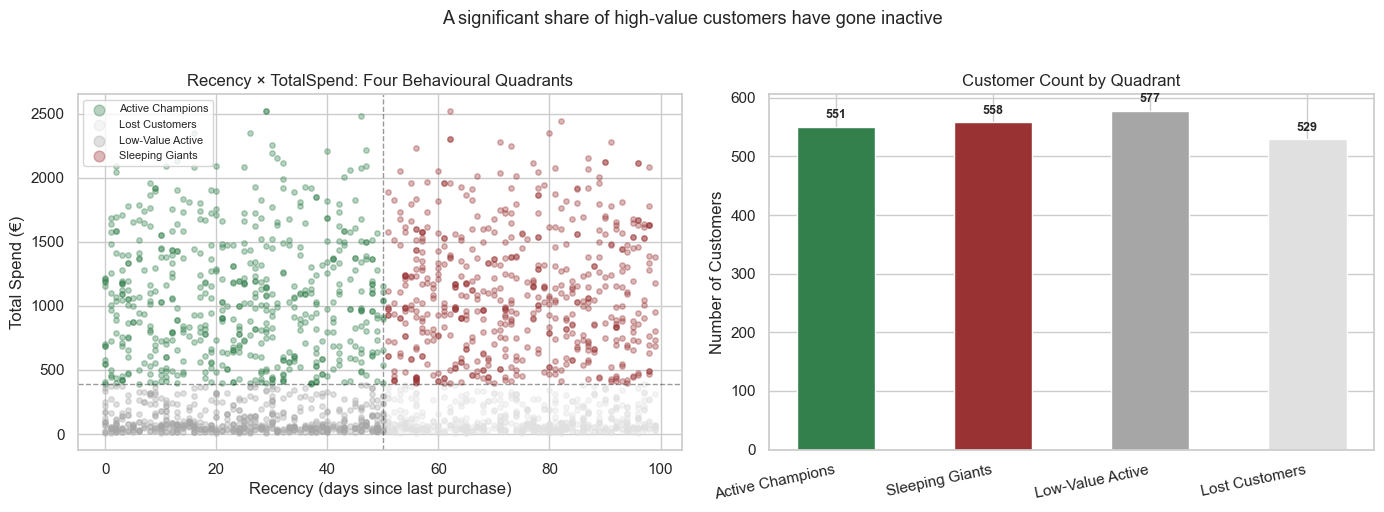

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quadrant_colors = {
    'Active Champions' : (0.2, 0.5, 0.3),
    'Sleeping Giants'  : (0.6, 0.2, 0.2),
    'Low-Value Active' : (0.65, 0.65, 0.65),
    'Lost Customers'   : (0.88, 0.88, 0.88)
}

for q, grp in df.groupby('Recency_Spend_Quadrant'):
    axes[0].scatter(
        grp['Recency'], grp['TotalSpend'],
        c=quadrant_colors[q], alpha=0.35, s=15, label=q
    )
axes[0].axvline(recency_median, color='black', linestyle='--', linewidth=1, alpha=0.4)
axes[0].axhline(spend_median,   color='black', linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Total Spend (€)')
axes[0].set_title('Recency × TotalSpend: Four Behavioural Quadrants')
axes[0].legend(fontsize=8, markerscale=2)

q_order  = ['Active Champions', 'Sleeping Giants', 'Low-Value Active', 'Lost Customers']
q_colors = [quadrant_colors[q] for q in q_order]
counts   = [quadrant_counts.get(q, 0) for q in q_order]
bars = axes[1].bar(q_order, counts, color=q_colors, edgecolor='white', width=0.5)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{int(bar.get_height())}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_title('Customer Count by Quadrant')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticklabels(q_order, rotation=12, ha='right')

fig.suptitle('A significant share of high-value customers have gone inactive',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The scatter plot reveals a clear and commercially significant pattern. The upper-right quadrant, **Sleeping Giants**, contains customers who historically spent above the median but have not purchased recently. Far from being a marginal group, they represent roughly the same number of customers as the Active Champions segment (558 vs 551).

The implication cuts against a common marketing assumption: the highest-value customers are not necessarily the most active ones today. Some of the company's best historical customers are quietly drifting away, and without this analysis they would remain invisible in a standard activity-based report.

In [32]:
# Profile comparison: Sleeping Giants vs Active Champions
profile_q = df[df['Recency_Spend_Quadrant'].isin(['Active Champions', 'Sleeping Giants'])]

profile_comparison = (
    profile_q.groupby('Recency_Spend_Quadrant')[
        ['Income', 'TotalSpend', 'Age', 'TotalChildren', 'Channels_Used', 'Recency']
    ].mean().round(1)
)
print('Profile comparison — Sleeping Giants vs Active Champions:')
profile_comparison

Profile comparison — Sleeping Giants vs Active Champions:


,Income,TotalSpend,Age,TotalChildren,Channels_Used,Recency
Recency_Spend_Quadrant,,,,,,
Active Champions,66900.30,1067.80,47.60,0.70,4.00,24.30
Sleeping Giants,67013.60,1105.60,48.60,0.70,4.00,74.00


The profile comparison is striking: Sleeping Giants and Active Champions share nearly identical income levels and total historical spending, they are structurally the same type of customer. The only meaningful difference is Recency.

This rules out explanations based on financial capacity or product mismatch. The disengagement is behavioral and temporal, not demographic, which means it is addressable. A reactivation campaign targeting Sleeping Giants does not need to convince them of the brand's value: they already demonstrated it through past spending. It needs to give them a relevant reason to return *now*.

### **2.4 High-Value Customers Engage More with Campaigns**

The dataset records whether each customer accepted any of five past marketing campaigns (`AcceptedCmp1–5`) alongside the most recent one (`Response`). Before designing a new communication strategy, there is a foundational question to answer: *did the previous campaigns actually reach the right customers?*

The implicit assumption in most campaign reporting is that responders are high-value customers, if someone accepted an offer, they must be engaged. This analysis tests that assumption directly against the spend data.

In [33]:
# Campaign acceptance vs customer value; quick overview
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df['AnyAccepted']   = df[campaign_cols].any(axis=1).map(
    {True: 'Accepted ≥1 Campaign', False: 'Never Accepted'})
df['TotalAccepted'] = df[campaign_cols].sum(axis=1)

# Are the best customers the most campaign-responsive?
high_spend_threshold = df['TotalSpend'].quantile(0.75)
rate_all  = df['AnyAccepted'].value_counts(normalize=True).mul(100).round(1)
rate_high = (df[df['TotalSpend'] >= high_spend_threshold]
             ['AnyAccepted'].value_counts(normalize=True).mul(100).round(1))

comparison = pd.DataFrame({
    'All Customers (%)' : rate_all,
    'Top 25% Spenders (%)': rate_high
}).fillna(0).round(1)

print(f'High-spend threshold (75th pct): €{high_spend_threshold:.0f}\n')
print(comparison)

High-spend threshold (75th pct): €1033

                      All Customers (%)  Top 25% Spenders (%)
AnyAccepted                                                  
Accepted ≥1 Campaign              26.80                 52.20
Never Accepted                    73.20                 47.80


Among the top 25% of spenders, 52.2% have accepted at least one campaign, compared with only 26.8% across the customer base. High-value customers are therefore almost twice as likely to engage with marketing campaigns. While this does not prove that campaigns caused the higher spending, it suggests that campaign engagement is strongly associated with customer value. Customers who respond to marketing communications tend to be among the retailer's most valuable buyers.

### **2.5 Hidden Trend: High-Intent, Low-Conversion Web Visitors**

The dataset contains a variable that is rarely examined on its own: `NumWebVisitsMonth`, the number of times a customer visits the company website per month. Paired with `NumWebPurchases`, it allows me to compute an implicit **conversion rate**: the fraction of website visits that actually result in a purchase.

This ratio is never made explicit in the data, it has to be derived. And when I derive it, a clear and strategically important pattern emerges.

High-visit / low-purchase customers: 773 (35.0% of web visitors)


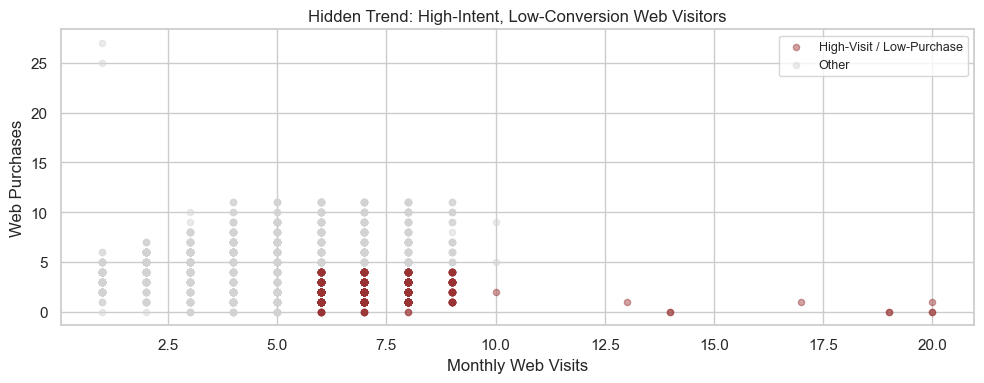

In [34]:
# Derive implicit web conversion rate
df_web = df[df['NumWebVisitsMonth'] > 0].copy()
df_web['WebConversionRate'] = (df_web['NumWebPurchases'] 
                                / df_web['NumWebVisitsMonth'])

visit_median    = df_web['NumWebVisitsMonth'].median()
purchase_median = df_web['NumWebPurchases'].median()
mask_window     = ((df_web['NumWebVisitsMonth'] >= visit_median) &
                   (df_web['NumWebPurchases']   <= purchase_median))

pct = mask_window.mean() * 100
print(f"High-visit / low-purchase customers: {mask_window.sum()} ({pct:.1f}% of web visitors)")

# One chart: visits vs purchases, window-shoppers highlighted
fig, ax = plt.subplots(figsize=(10, 4))
colors_map = {'Other': 'lightgray', 'High-Visit / Low-Purchase': (0.6, 0.2, 0.2)}
df_web['Visitor_Type'] = 'Other'
df_web.loc[mask_window, 'Visitor_Type'] = 'High-Visit / Low-Purchase'

for vtype, grp in df_web.groupby('Visitor_Type'):
    ax.scatter(grp['NumWebVisitsMonth'], grp['NumWebPurchases'],
               c=colors_map[vtype], alpha=0.45, s=20, label=vtype)
ax.set_xlabel('Monthly Web Visits')
ax.set_ylabel('Web Purchases')
ax.set_title('Hidden Trend: High-Intent, Low-Conversion Web Visitors', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Approximately 35% of web-active customers visit the website frequently but make relatively few online purchases. This identifies a sizeable group of customers who show repeated interest without converting.

Frequent visits suggest that awareness is not the issue. Instead, the pattern points to a conversion gap: customers are reaching the website but are not completing purchases at the expected rate.

**Recommended lever**: trigger behavioural retargeting after repeated category visits without purchase. Personalised product recommendations are likely to be more effective than broad promotional campaigns, as the challenge appears to be conversion rather than traffic generation.

### **2.6 EDA Summary**

Four findings shape the segmentation and communication strategy that follow.

**Customer value is highly concentrated and follows clear demographic patterns**. Income is the strongest driver of spending, but it does not act alone. Spending also varies substantially by household composition and age: child-free customers spend more than twice as much as households with children, particularly in premium categories such as Wines and Meat, while customers aged 51+ consistently outperform younger cohorts. Channel behaviour reinforces these differences, with high-value customers favouring Catalog and Store purchases, whereas lower-value segments rely more heavily on Deals.

**A significant share of valuable customers is becoming inactive**. The Recency × TotalSpend analysis identifies a large group of Sleeping Giants: customers whose income, age profile and historical spending closely match those of the Active Champions segment, but whose recent activity has declined. Their disengagement appears temporal rather than structural, making them a prime target for reactivation campaigns.

**Customer value is strongly associated with campaign engagement**. More than half of the top 25% spenders have accepted at least one marketing campaign, compared with only 26.8% of customers overall. While this does not establish causality, it suggests that campaign engagement is concentrated among the retailer's most valuable customers and should be considered an important behavioural signal in subsequent segmentation analyses.

**A web conversion gap represents a clear growth opportunity**. Approximately 35% of web-active customers visit the website frequently but complete relatively few online purchases. The issue does not appear to be awareness or traffic generation; rather, it reflects a gap between interest and conversion. Behavioural retargeting and personalised product recommendations are therefore more appropriate interventions than broad acquisition campaigns.

These findings reveal *where customer value is created*, *where it is at risk*, and *where untapped opportunities exist*. The RFM segmentation in Section 3 translates these patterns into actionable customer groups that can support differentiated communication and retention strategies.

## 3. RFM Calculation and Heuristic Segmentation

The Exploratory Data Analysis conducted in section 2 addressed a key question: *who are our customers, and where is value leaking?*. This section translates the qualitative findings into a structured and quantifiable segmentation through the **RFM framework**.

RFM classifies customers along three behavioral dimensions:
- **Recency (R)**: how recently a customer made a purchase  
- **Frequency (F)**: how often a customer purchases  
- **Monetary (M)**: how much a customer spends  

RFM belongs to the deterministic segmentation layer and provides an interpretable, business-oriented view of the customer lifecycle. Rather than describing customer demographics, it focuses on customer behaviour and relationship strength, making it particularly useful for marketing prioritisation and campaign design.

The objective is to identify customers who are actively engaged, at risk of disengagement, highly valuable, or largely inactive, and to associate each behavioural profile with an appropriate marketing response.

This analysis also serves as a bridge between the exploratory findings and the predictive modelling developed later. Several patterns observed in Section 2, such as the existence of high-value inactive customers, the concentration of value among a limited share of the customer base, and the presence of distinct behavioural profiles, can now be formalised through a consistent behavioural framework.

In this way, RFM does not replace the insights obtained during EDA; it transforms them into actionable customer segments that can be directly targeted through differentiated communication and retention strategies.

In [35]:
# Setup for segmentation phase
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PALETTE    = sns.color_palette('YlOrRd', 6)
SEG_COLORS = {
    'Champions'             : (0.18, 0.42, 0.33),
    'Sleeping Giants'       : (0.55, 0.22, 0.22),
    'Loyal Mid-Spenders'    : (0.25, 0.38, 0.55),
    'Price-Sensitive'       : (0.72, 0.58, 0.28),
    'At Risk / Lost'        : (0.65, 0.65, 0.65),
    'New / Occasional Buyer': (0.72, 0.38, 0.12),   
    'Other'                 : (0.90, 0.90, 0.90),
}

CLUSTER_COLORS = {
    0: (0.28, 0.42, 0.60),   
    1: (0.60, 0.20, 0.20)    
}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.titlesize': 12, 'axes.labelsize': 10,
                     'xtick.labelsize': 9, 'ytick.labelsize': 9, 'figure.dpi': 110})
print('Setup complete.')

Setup complete.


### **3.1 RFM Feature Engineering**

The three RFM dimensions are derived as follows, with explicit justification for each construction choice:

- **Recency**: the `Recency` column in the dataset directly records the number of days since a customer's last purchase. This is used as-is; it is the most precise and dataset-appropriate measure of recency. `Dt_Customer`, by contrast, measures enrollment tenure, not purchase recency, and would be the wrong variable here.

- **Frequency**: no single column records total purchase count. It is derived as the sum of purchases across all four channels: Web, Catalog, Store, and Deals. This captures *all* buying behaviour regardless of channel, which is the correct scope for an RFM model focused on overall engagement, not channel-specific activity.

- **Monetary**: `TotalSpend`, engineered in section 1.3 as the sum of all product category expenditure, is the natural choice. Since the dataset does not provide transaction-level granularity, a per-transaction average cannot be computed. `TotalSpend` captures the full commercial value each customer has generated over the observation period.

In [36]:
# R — Recency: days since last purchase (already present in dataset)
df['R'] = df['Recency']

# F — Frequency: total purchases across all four channels
channel_cols_rfm = ['NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumDealsPurchases']
df['F'] = df[channel_cols_rfm].sum(axis=1)

# M — Monetary: total product spend (engineered in section 1.3)
df['M'] = df['TotalSpend']

print('RFM dimensions constructed.')
print(df[['R', 'F', 'M']].agg(['min', 'median', 'max', 'mean']).round(1))

RFM dimensions constructed.
           R     F       M
min     0.00  0.00    5.00
median 50.00 15.00  393.00
max    99.00 43.00 2525.00
mean   49.20 14.80  599.20


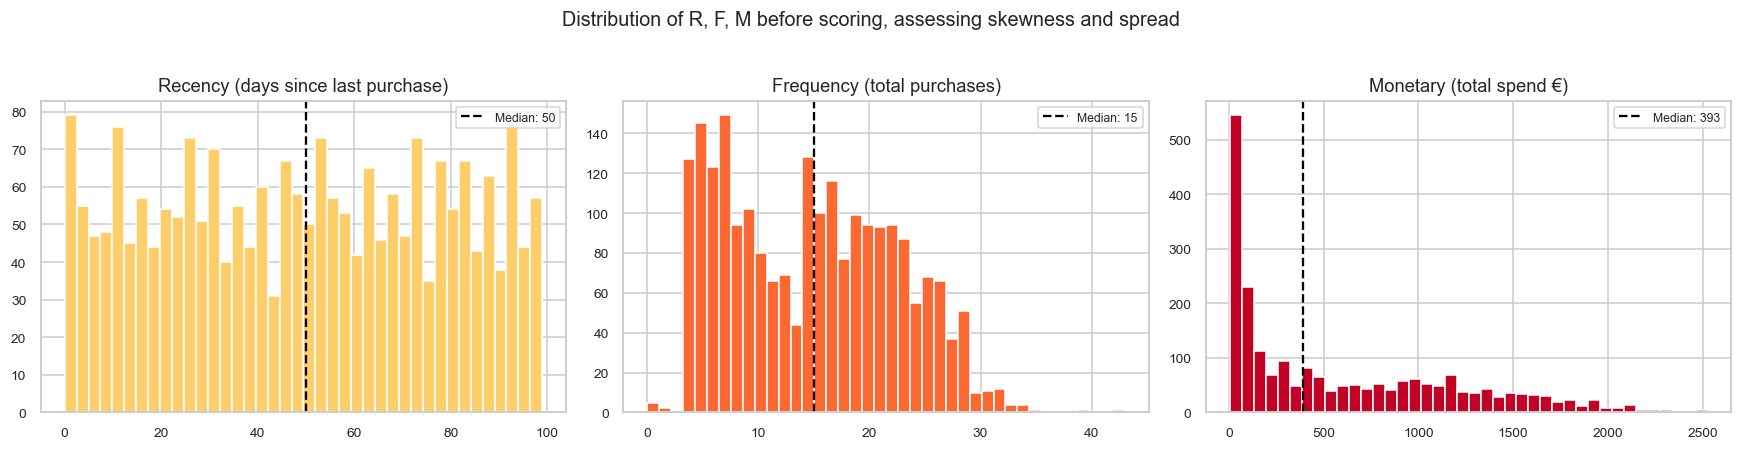

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label, color in zip(
    axes,
    ['R', 'F', 'M'],
    ['Recency (days since last purchase)',
     'Frequency (total purchases)',
     'Monetary (total spend €)'],
    [PALETTE[1], PALETTE[3], PALETTE[5]]
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white')
    ax.axvline(df[col].median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {df[col].median():.0f}')
    ax.set_title(label)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of R, F, M before scoring, assessing skewness and spread',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The distributions confirm the patterns already suggested by the descriptive statistics. **Recency** is approximately uniform across the 0–99 day range, with no strong concentration around either recent or distant purchases. This allows the RFM scoring procedure to differentiate customers relatively evenly along the recency dimension.

**Frequency** exhibits a moderate right skew: most customers make between 5 and 20 purchases, while a smaller group reaches substantially higher purchase counts. This indicates that highly engaged customers exist, but they represent a minority of the customer base.

**Monetary** is by far the most asymmetric dimension. Most customers spend less than €500, while a relatively small group accounts for substantially higher spending levels, extending well beyond €1,500. The long right tail highlights a strong concentration of customer value, a common pattern in retail environments where a limited share of customers generates a disproportionate share of revenue.

This distributional structure is precisely what makes RFM segmentation valuable: Recency and Frequency distinguish engagement levels, while Monetary separates the small group of high-value customers from the broader customer base.

### **3.2 Quintile Scoring**

Each RFM dimension is divided into five equally populated bands (quintiles), and customers are assigned a score from 1 to 5.

One critical asymmetry applies: for Recency, a lower value (more recent purchase) is better, so the scoring direction is inverted. Score 5 is assigned to the most recent customers (lowest R), and score 1 to the least recent (highest R). For Frequency and Monetary, higher values receive higher scores.

This inversion ensures that the composite `RFM_Score` is monotonically aligned with customer value. Without it, a customer who bought yesterday and one who bought 99 days ago would receive the same interpretation, which is analytically incoherent.

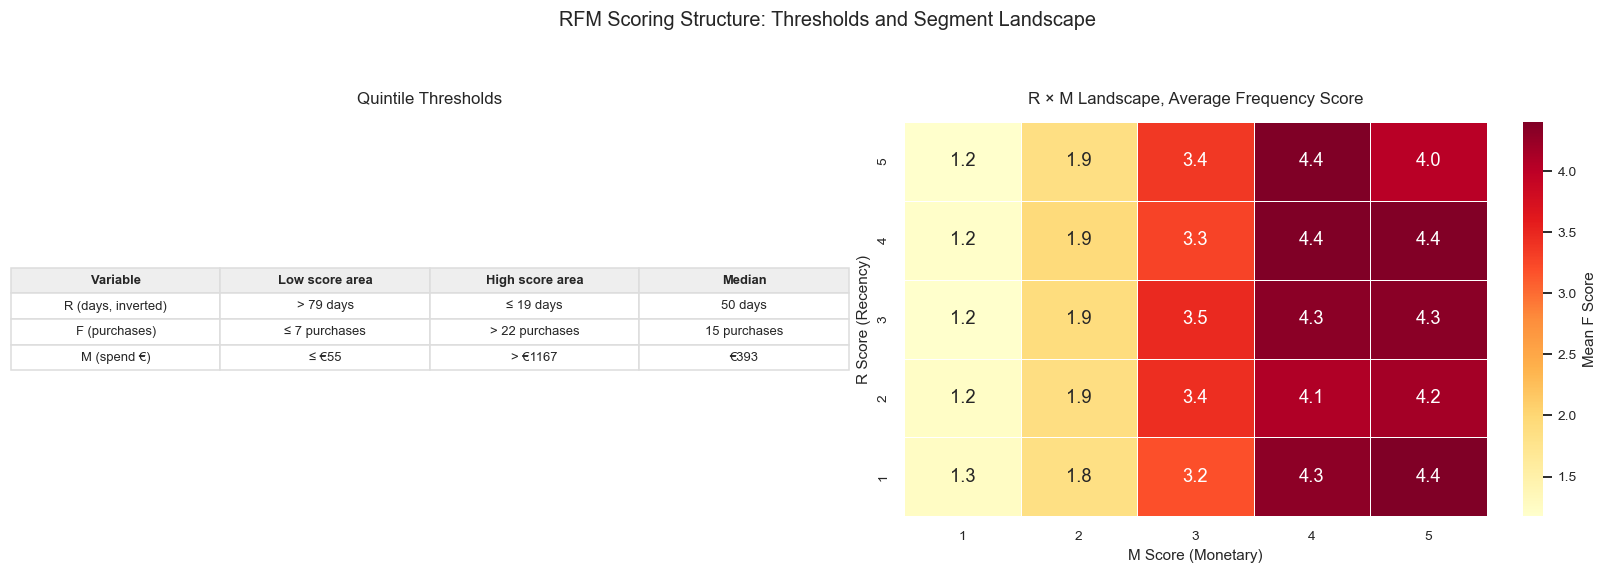

In [38]:
# Recency: lower is better -> inverted labels
df['R_Score'] = pd.qcut(df['R'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency and Monetary: higher is better
df['F_Score'] = pd.qcut(df['F'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
df['M_Score'] = pd.qcut(df['M'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Composite indicators
df['RFM_Label'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

# Quintile boundaries
bounds = pd.DataFrame({
    'Variable': ['R (days, inverted)', 'F (purchases)', 'M (spend €)'],
    'Low score area': [f"> {df['R'].quantile(0.8):.0f} days", f"≤ {df['F'].quantile(0.2):.0f} purchases", f"≤ €{df['M'].quantile(0.2):.0f}"],
    'High score area': [f"≤ {df['R'].quantile(0.2):.0f} days", f"> {df['F'].quantile(0.8):.0f} purchases", f"> €{df['M'].quantile(0.8):.0f}"],
    'Median': [f"{df['R'].median():.0f} days", f"{df['F'].median():.0f} purchases", f"€{df['M'].median():.0f}"]
})

# Heatmap data 
heatmap_data = df.groupby(['R_Score', 'M_Score'])['F_Score'].mean().unstack().sort_index(ascending=False)

# Plot: table + heatmap 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: table
axes[0].axis('off')
table = axes[0].table(cellText=bounds.values, colLabels=bounds.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1.15, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0: cell.set_text_props(weight='bold'); cell.set_facecolor('#eeeeee')
    cell.set_edgecolor('#dddddd')

axes[0].set_title('Quintile Thresholds', fontsize=11, pad=12)

# Right: heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Mean F Score'})

axes[1].set_xlabel('M Score (Monetary)'); axes[1].set_ylabel('R Score (Recency)')
axes[1].set_title('R × M Landscape, Average Frequency Score', fontsize=11, pad=12)

# Title
fig.suptitle('RFM Scoring Structure: Thresholds and Segment Landscape', fontsize=13, y=1.04)

plt.tight_layout(); plt.show()

The resulting score distributions produce a balanced segmentation structure. The quintile thresholds ensure that each score level contains approximately the same number of customers, avoiding segments that are either too small to target or too broad to differentiate.

The heatmap further confirms that **Monetary value and Frequency are strongly aligned**: customers with high Monetary scores tend to exhibit high Frequency scores as well. In contrast, Recency varies more independently, highlighting the distinction between active high-value customers and previously valuable customers who have recently become inactive. This separation is one of the key strengths of the RFM framework, as it allows customer value and customer engagement to be analysed simultaneously.

### **3.3 Segment Definition**

Six segments are defined using rule-based assignment on the individual R, F, and M scores. The rules are applied in a strict priority order because the conditions can overlap. For example, a customer with R=1, F=2, M=5 satisfies both the *Sleeping Giants* and *At Risk / Lost* conditions; therefore, the order of evaluation determines the final assignment.

The priority logic is as follows:

1. **Champions** are evaluated first because they represent the highest-value active customers.
2. **Sleeping Giants** are evaluated second, ensuring that historically valuable but inactive customers are identified before any low-engagement rule is applied.
3. **Loyal Mid-Spenders** and **Price-Sensitive** customers are evaluated next, distinguished primarily by their Monetary score.
4. **At Risk / Lost** captures customers with simultaneously low Recency, Frequency, and Monetary scores.
5. **New / Occasional Buyers** identify recent customers who have not yet developed strong purchasing behaviour.
6. Customers not matching any of the above profiles are assigned to the residual **Other** category.

| Segment                    | Rule          | Behavioral Logic                                                                        |
| -------------------------- | ------------- | --------------------------------------------------------------------------------------- |
| **Champions**              | R≥3, F≥4, M≥4 | High-value active customers with strong recency, frequency, and spending patterns       |
| **Sleeping Giants**        | R≤2, M≥4      | Historically high-value customers who have become inactive; primary reactivation target |
| **Loyal Mid-Spenders**     | F≥3, 2≤M≤3    | Consistently active customers with moderate spending; growth potential                  |
| **Price-Sensitive**        | F≥2, M≤2      | Repeat purchasers with low spend levels; promotion-driven and margin-sensitive          |
| **At Risk / Lost**         | R≤2, F≤2, M≤3 | Low engagement, low frequency, and low value; customers with limited recovery potential |
| **New / Occasional Buyer** | R≥3, F≤2, M≤2 | Recent customers with limited purchase history; potential for onboarding and activation |
| **Other**                  | —             | Customers whose behavioural profile does not clearly match any predefined segment       |

Customers in the **Other** group do not satisfy the defining conditions of any of the six named segments. This is a natural consequence of rule-based segmentation: some customers occupy intermediate positions between clearly defined behavioural profiles. The objective of this framework is not exhaustive classification, but the identification of strategically meaningful customer archetypes. For the purposes of this analysis, the Other category is retained as a residual group and excluded from the strategic profiling, ensuring that the identified segments remain behaviourally distinct and operationally actionable.


### **3.4 Segment Profiling**

With segments defined, the focus shifts from classification to interpretation. Each segment is profiled across its core RFM dimensions and key demographic variables to build a complete behavioral and economic portrait.

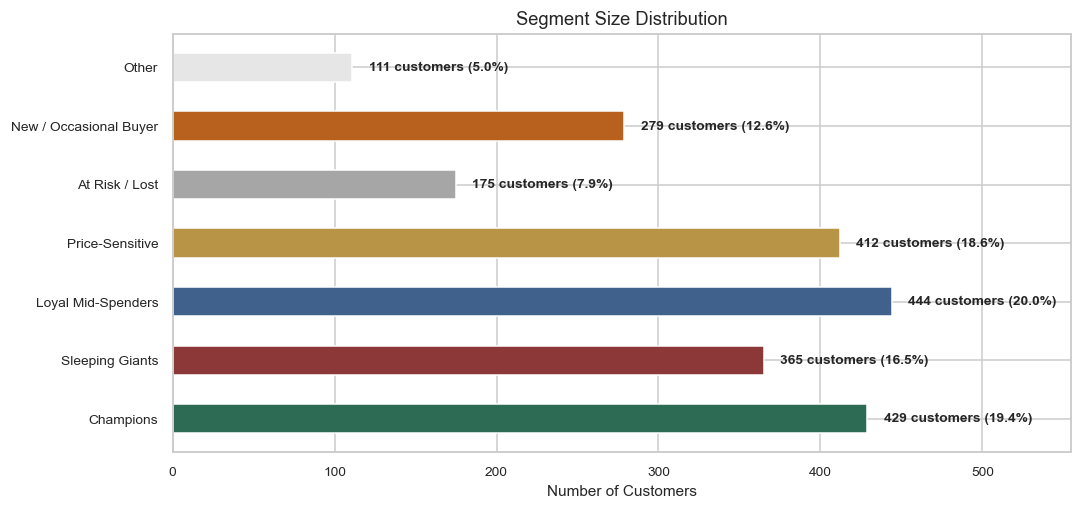

In [39]:
# Segment size overview with broader, more balanced RFM rules

def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # 1. High-value active customers
    if r >= 3 and f >= 4 and m >= 4:
        return 'Champions'
    
    # 2. High-value inactive customers
    if r <= 2 and m >= 4:
        return 'Sleeping Giants'
    
    # 3. Stable mid-value customers
    if f >= 3 and 2 <= m <= 3:
        return 'Loyal Mid-Spenders'
    
    # 4. Low monetary value but repeated purchasing behaviour
    if f >= 2 and m <= 2:
        return 'Price-Sensitive'
    
    # 5. Inactive and weakly engaged customers
    if r <= 2 and f <= 2 and m <= 3:
        return 'At Risk / Lost'
    
    # 6. Recent but low-engagement buyers
    if r >= 3 and f <= 2 and m <= 2:
        return 'New / Occasional Buyer'
    
    return 'Other'

df['Segment'] = df.apply(assign_segment, axis=1)

order = [
    'Champions',
    'Sleeping Giants',
    'Loyal Mid-Spenders',
    'Price-Sensitive',
    'At Risk / Lost',
    'New / Occasional Buyer',
    'Other'
]

plot_colors = SEG_COLORS

seg_size = (
    df['Segment']
    .value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
    .reset_index()
)

seg_size.columns = ['Segment', 'N']
seg_size['% of total'] = (seg_size['N'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4.8))

bars = ax.barh(
    seg_size['Segment'],
    seg_size['N'],
    color=[plot_colors[s] for s in seg_size['Segment']],
    edgecolor='white',
    height=0.5
)

for bar, pct in zip(bars, seg_size['% of total']):
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} customers ({pct}%)',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlabel('Number of Customers')
ax.set_title('Segment Size Distribution', fontsize=12)
ax.set_xlim(0, seg_size['N'].max() * 1.25)

plt.tight_layout()
plt.show()

The segment distribution highlights a clear concentration of customers in a small number of behavioural profiles. **Loyal Mid-Spenders** represent the largest segment, forming the stable commercial core of the business: customers who purchase regularly but have not yet reached the spending levels of the highest-value groups.

**Sleeping Giants** remain one of the most strategically important segments. Their size confirms that customer inactivity is not limited to low-value buyers; a substantial share of historically valuable customers has become disengaged and therefore represents a significant reactivation opportunity.

**Champions** account for a smaller share of the customer base but concentrate the highest levels of engagement and spending. This pattern is consistent with the value concentration typically observed in retail environments, where a relatively limited group of customers generates a disproportionate share of revenue.

The introduction of **New / Occasional Buyers** also reveals a meaningful population of recent customers who have not yet developed strong purchasing habits. These customers represent the primary onboarding and activation opportunity within the customer lifecycle.

Finally, the residual **Other** category captures customers with mixed behavioural profiles that do not naturally fit any predefined archetype. Retaining this group separately preserves the interpretability of the named segments while avoiding arbitrary assignments.


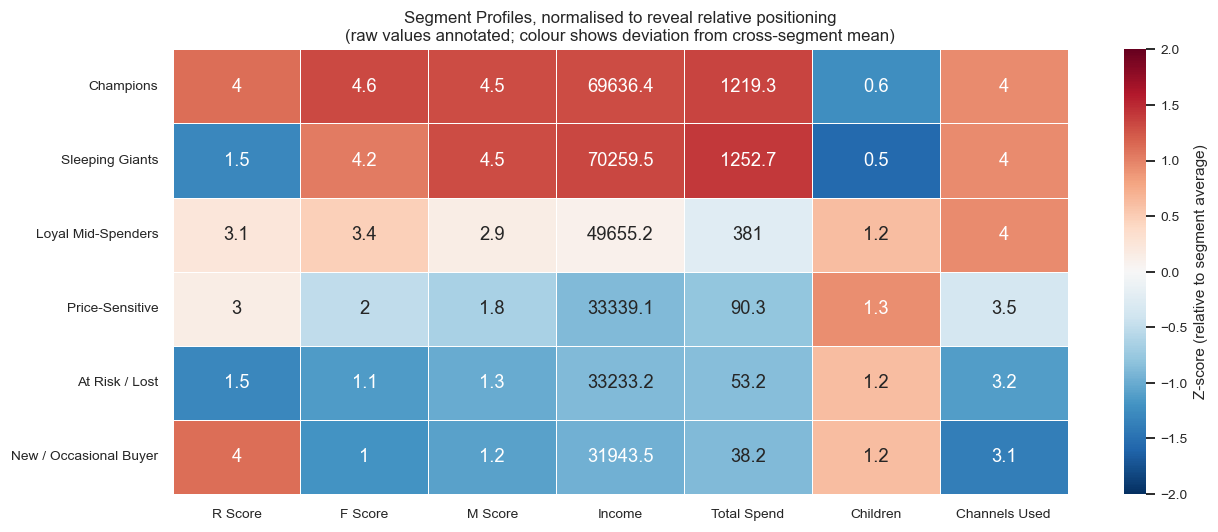

In [ ]:
if 'Segment' not in df.columns:
    def assign_segment(row):
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
        if r >= 3 and f >= 4 and m >= 4:
            return 'Champions'
        if r <= 2 and m >= 4:
            return 'Sleeping Giants'
        if f >= 3 and 2 <= m <= 3:
            return 'Loyal Mid-Spenders'
        if f >= 2 and m <= 2:
            return 'Price-Sensitive'
        if r <= 2 and f <= 2 and m <= 3:
            return 'At Risk / Lost'
        if r >= 3 and f <= 2 and m <= 2:
            return 'New / Occasional Buyer'
        
        return 'Other'
    df['Segment'] = df.apply(assign_segment, axis=1)

order      = ['Champions', 'Sleeping Giants', 'Loyal Mid-Spenders',
              'Price-Sensitive', 'At Risk / Lost', 'New / Occasional Buyer']
named_segs = df[df['Segment'] != 'Other']

profile_cols = ['R_Score', 'F_Score', 'M_Score', 'RFM_Score',
                'Income', 'TotalSpend', 'Age', 'TotalChildren', 'Channels_Used']
profile = (
    named_segs.groupby('Segment')[profile_cols]
    .mean().loc[order].round(1)
)

# Normalised heatmap to show relative segment positioning across key metrics
features_to_show = ['R_Score', 'F_Score', 'M_Score',
                    'Income', 'TotalSpend', 'TotalChildren', 'Channels_Used']
feature_labels   = ['R Score', 'F Score', 'M Score',
                    'Income', 'Total Spend', 'Children', 'Channels Used']

profile_norm = profile[features_to_show].apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    profile_norm,
    annot=profile[features_to_show].round(1),
    fmt='g',
    cmap='RdBu_r', center=0, vmin=-2, vmax=2,
    linewidths=0.5, linecolor='white',
    xticklabels=feature_labels,
    ax=ax,
    cbar_kws={'label': 'Z-score (relative to segment average)'}
)
ax.set_title('Segment Profiles, normalised to reveal relative positioning\n'
             '(raw values annotated; colour shows deviation from cross-segment mean)',
             fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The normalised heatmap makes the segment differentiation immediately visible. **Champions** and **Sleeping Giants** clearly stand apart from the rest on both Income and TotalSpend, confirming that they represent the commercial top tier of the customer base. The key distinction lies in Recency: Champions exhibit very high R scores, whereas Sleeping Giants show very low ones. In other words, they have comparable purchasing power and historical value, but very different levels of recent engagement. This formally validates the interpretation emerging from the EDA: Sleeping Giants are not low-value customers, they are high-value customers who have become inactive. The appropriate intervention is therefore reactivation rather than acquisition.

**Price-Sensitive** customers display a different behavioural pattern. Their defining characteristic is not low activity but low value generation: despite purchasing relatively regularly, their Monetary scores remain substantially below those of the other segments. Their spending levels are the lowest among all actively engaged groups, suggesting a strong focus on promotions, discounts, or lower-priced products. This makes them an important segment from a volume perspective, but a less attractive one from a margin perspective.

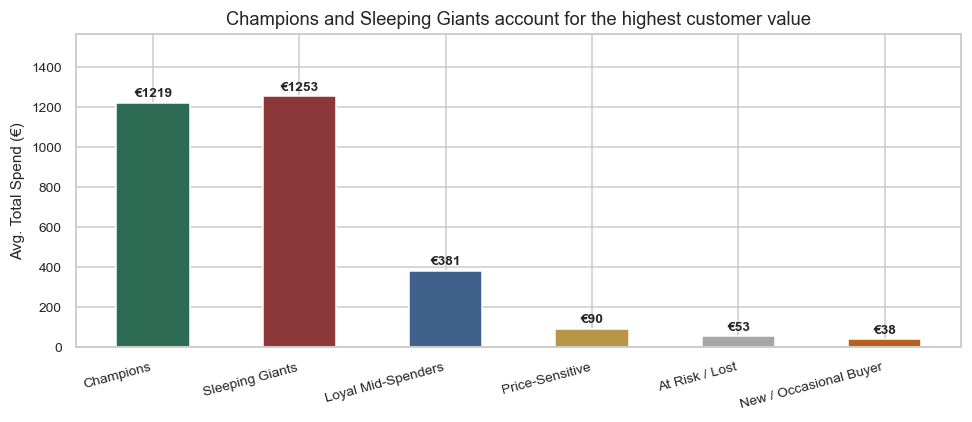

In [41]:
# Mean TotalSpend per segment
order_clean = [s for s in order if s != 'Other']
spend_seg = named_segs.groupby('Segment')['TotalSpend'].mean().loc[order_clean]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    spend_seg.index, spend_seg.values,
    color=[SEG_COLORS[s] for s in spend_seg.index],
    edgecolor='white', width=0.5
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'€{bar.get_height():.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
ax.set_xticklabels(spend_seg.index, rotation=15, ha='right')
ax.set_title('Champions and Sleeping Giants account for the highest customer value',
             fontsize=12)
ax.set_ylabel('Avg. Total Spend (€)')
ax.set_ylim(0, spend_seg.max() * 1.25)
plt.tight_layout()
plt.show()

The average spend gap between segments is substantial. Champions and Sleeping Giants both average more than €1,200 in total spend, over three times the value of Loyal Mid-Spenders (€381) and roughly fourteen times that of Price-Sensitive customers (€90). This concentration of value confirms that the highest-value segments account for a disproportionate share of customer revenue despite representing less than half of the customer base. Most importantly, Sleeping Giants spend slightly more on average than Champions (€1,253 vs €1,219), reinforcing the central insight of the analysis: these are not low-value customers who disengaged, but some of the most valuable customers in the database. Each successfully reactivated Sleeping Giant therefore represents a potentially significant recovery of revenue.

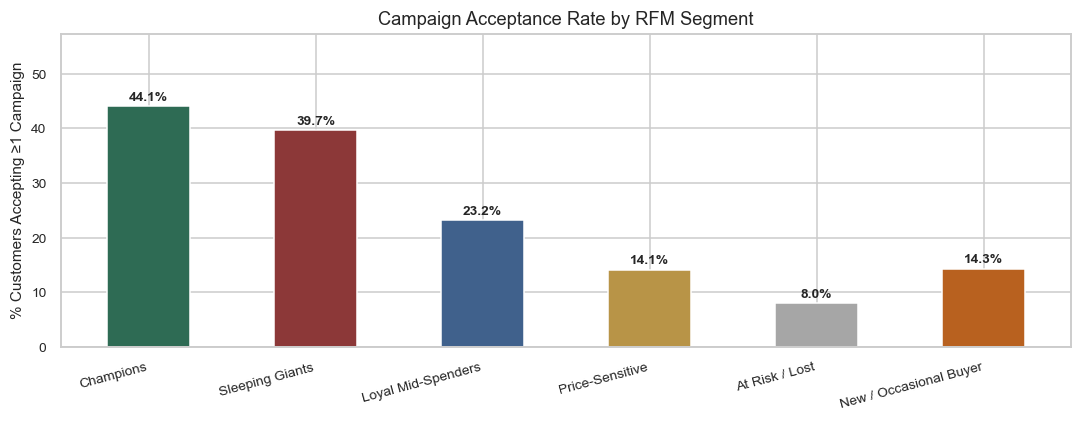

In [42]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

named_segs = named_segs.copy()
named_segs['AnyAccepted'] = df.loc[named_segs.index, campaign_cols].any(axis=1).astype(int)

campaign_by_seg = (
    named_segs.groupby('Segment')['AnyAccepted']
    .mean()
    .mul(100).round(1)
    .loc[order_clean]
    .reset_index()
    .rename(columns={'AnyAccepted': 'Campaign Acceptance Rate (%)'})
)

fig, ax = plt.subplots(figsize=(10, 4))
bar_container = ax.bar(
    campaign_by_seg['Segment'],
    campaign_by_seg['Campaign Acceptance Rate (%)'],
    color=[SEG_COLORS[s] for s in campaign_by_seg['Segment']],
    edgecolor='white', width=0.5
)
for bar in bar_container:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
ax.set_title('Campaign Acceptance Rate by RFM Segment', fontsize=12)
ax.set_ylabel('% Customers Accepting ≥1 Campaign')
ax.set_xticklabels(campaign_by_seg['Segment'], rotation=15, ha='right')
ax.set_ylim(0, campaign_by_seg['Campaign Acceptance Rate (%)'].max() * 1.3)
plt.tight_layout()
plt.show()

The campaign acceptance analysis reveals a clear gradient across customer value segments. Champions exhibit the highest acceptance rate (44.1%), closely followed by Sleeping Giants (39.7%), while acceptance steadily declines among lower-value segments. This indicates that campaign responsiveness is positively associated with customer value and engagement.

The result refines the preliminary observation from the EDA. At the aggregate level, campaign acceptance appeared only weakly related to spending, but the segment-level analysis reveals substantial heterogeneity. High-value customers are not uniformly resistant to marketing campaigns; rather, responsiveness varies according to their position in the customer lifecycle.

From a managerial perspective, this is encouraging. Sleeping Giants combine high historical value with relatively strong campaign responsiveness, making them particularly attractive targets for reactivation initiatives. Champions, meanwhile, remain highly engaged and responsive, suggesting that retention-focused communications can reinforce an already valuable relationship.

### **3.5 Business Interpretation**

Segmentation is only analytically complete when each segment is connected to a specific marketing action. A cluster is not useful if it is mathematically good but not interpretable and interpretability is ultimately measured by whether the segment can be linked to a differentiated, actionable communication lever.

The table below translates each segment into a full strategic specification: behavioral state, economic value, recommended channel, communication lever, and KPI.

In [43]:
strategy = pd.DataFrame([
    {
        'Segment': 'Champions',
        'Avg. Spend': '€1219',
        'Primary Channel': 'Catalog + personalised email',
        'Communication Lever': 'Loyalty recognition, early access, curated selections. No discounts.',
        'KPI': 'Retention rate; avg spend stability'
    },
    {
        'Segment': 'Sleeping Giants',
        'Avg. Spend': '€1253',
        'Primary Channel': 'Email + Catalog',
        'Communication Lever': 'We noticed you messaging; product curation based on previous purchases.',
        'KPI': 'Reactivation rate within 60 days'
    },
    {
        'Segment': 'Loyal Mid-Spenders',
        'Avg. Spend': '€381',
        'Primary Channel': 'Store + Web',
        'Communication Lever': 'Upsell towards Wines and Meat categories; encourage omnichannel usage.',
        'KPI': 'Average spend growth; channel breadth'
    },
    {
        'Segment': 'Price-Sensitive',
        'Avg. Spend': '€90',
        'Primary Channel': 'Deals + Store',
        'Communication Lever': 'Targeted promotions and bundles; gradual introduction of mid-tier products.',
        'KPI': 'Purchase frequency; basket value'
    },
    {
        'Segment': 'At Risk / Lost',
        'Avg. Spend': '€53',
        'Primary Channel': 'Email + Retargeting',
        'Communication Lever': 'Single win-back campaign with limited-time incentive.',
        'KPI': 'Win-back rate; campaign ROI'
    },
    {
        'Segment': 'New / Occasional Buyer',
        'Avg. Spend': '€38',
        'Primary Channel': 'Web + Email',
        'Communication Lever': 'Onboarding journey, discovery content, first-repeat-purchase incentives.',
        'KPI': 'Second purchase rate'
    }
])

In [44]:
# Display-friendly strategy table

pd.set_option('display.max_colwidth', None)

strategy_display = (
    strategy
    .set_index('Segment')
    .style
    .set_table_styles([
        {'selector': 'th',
         'props': [('text-align', 'left'),
                   ('font-size', '11pt')]},
        {'selector': 'td',
         'props': [('white-space', 'normal'),
                   ('text-align', 'left'),
                   ('vertical-align', 'top'),
                   ('padding', '8px')]}
    ])
    .set_properties(subset=['Avg. Spend'], **{
        'width': '90px'
    })
    .set_properties(subset=['Primary Channel'], **{
        'width': '180px'
    })
    .set_properties(subset=['Communication Lever'], **{
        'width': '450px'
    })
    .set_properties(subset=['KPI'], **{
        'width': '220px'
    })
)

strategy_display

,Avg. Spend,Primary Channel,Communication Lever,KPI
Segment,,,,
Champions,€1219,Catalog + personalised email,"Loyalty recognition, early access, curated selections. No discounts.",Retention rate; avg spend stability
Sleeping Giants,€1253,Email + Catalog,We noticed you messaging; product curation based on previous purchases.,Reactivation rate within 60 days
Loyal Mid-Spenders,€381,Store + Web,Upsell towards Wines and Meat categories; encourage omnichannel usage.,Average spend growth; channel breadth
Price-Sensitive,€90,Deals + Store,Targeted promotions and bundles; gradual introduction of mid-tier products.,Purchase frequency; basket value
At Risk / Lost,€53,Email + Retargeting,Single win-back campaign with limited-time incentive.,Win-back rate; campaign ROI
New / Occasional Buyer,€38,Web + Email,"Onboarding journey, discovery content, first-repeat-purchase incentives.",Second purchase rate


## 4. Unsupervised Learning (Cluster Analysis)

Section 3 produced seven RFM segments built on three behavioral dimensions: Recency, Frequency, and Monetary value. The segments are interpretable and directly actionable, but they carry an inherent limitation: they can only see what they were designed to see. A customer with high TotalSpend on wines and a customer with high TotalSpend distributed across all categories receive the same RFM classification, yet they represent fundamentally different profiles for product targeting and communication.

Cluster analysis addresses this blind spot. By operating on a richer feature space, including product category mix, demographic variables, and channel behavior simultaneously, it allows the data to surface structure that no predefined rule system could capture. The algorithm does not impose a segmentation logic; it discovers one.

The two approaches are not in competition. They answer different questions:
- **RFM** answers: *where is this customer in their lifecycle with the brand?*
- **Clustering** answers: *what type of customer is this, across all behavioral dimensions simultaneously?*

Used together, they produce a segmentation that is both temporally aware and behaviorally rich. This section builds the cluster solution, validates it statistically, and then maps it against the RFM segments to identify where the two approaches agree, and where clustering reveals something new.

In [45]:
# Colour palette for clusters (up to 6)
CATEGORY_COLORS = [
    (0.48, 0.35, 0.65),   
    (0.70, 0.42, 0.55),   
    (0.82, 0.65, 0.35),   
    (0.38, 0.55, 0.70),   
    (0.42, 0.65, 0.60),   
    (0.60, 0.55, 0.70)    
]
print('Libraries loaded.')

Libraries loaded.


### **4.1 Feature Selection and Preprocessing**

The quality of a clustering solution depends critically on the choice of input features. Including irrelevant or redundant variables inflates dimensionality, distorts distance calculations, and produces clusters that are statistically compact but strategically uninterpretable. The feature selection here is therefore deliberate and motivated by the EDA findings in Section 2.

Two categories of variables are included:

**Customer profile and behavioural dimensions:** the variables that Section 2 identified as the primary drivers of customer value and differentiation: `Income`, `TotalSpend`, `Recency`, `F` (total purchase frequency), `TotalChildren`, and `Channels_Used`. Together, these variables capture behavioural activity (Recency, Frequency, TotalSpend, Channels_Used), economic capacity (Income), and household composition (TotalChildren). These are the same dimensions that anchored both the EDA analysis and the RFM segmentation.

**Product category mix:** `MntWines`, `MntMeatProducts`, `MntFruits`, `MntFishProducts`, `MntSweetProducts`, and `MntGoldProds`. These variables are deliberately excluded from RFM, which relies only on aggregate spending. Including them here allows the clustering to capture *what* customers buy, not only how much they spend. If clusters emerge that differ primarily in category composition, this represents genuinely additional information that rule-based segmentation cannot capture.

**Excluded variables:** binary campaign-response flags (`AcceptedCmp1–5`, `Response`, `Complain`), ID columns, date fields, and derived categorical features (`Income_Segment`, `Age_Group`) are excluded. The campaign-response variables represent outcomes rather than intrinsic customer characteristics. Including them would risk generating clusters driven by past campaign behaviour instead of underlying customer profiles. The remaining excluded variables are either non-metric, redundant, or unsuitable for distance-based clustering.

**Preprocessing (StandardScaler):** K-Means relies on Euclidean distance. Without scaling, variables with large numerical ranges (e.g., Income: €1,730–€94,384) would dominate the distance calculation over variables with smaller ranges (e.g., TotalChildren: 0–3), regardless of their actual analytical relevance. StandardScaler transforms each feature to mean = 0 and standard deviation = 1, ensuring that all dimensions contribute proportionally to the clustering process.

In [46]:
# Feature selection 
feature_cols = [
    # Core value dimensions
    'Income', 'TotalSpend', 'Recency', 'F',
    'TotalChildren', 'Channels_Used',
    # Product category mix, invisible to RFM
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

if 'F' not in df.columns:
    df['F'] = df[['NumWebPurchases', 'NumCatalogPurchases',
                  'NumStorePurchases', 'NumDealsPurchases']].sum(axis=1)

X_raw = df[feature_cols].copy()

print(f'Feature matrix: {X_raw.shape[0]} customers × {X_raw.shape[1]} features')
print(f'Missing values: {X_raw.isna().sum().sum()}')
X_raw.describe().T[['mean', 'std', 'min', 'max']].round(1)

Feature matrix: 2215 customers × 12 features
Missing values: 0


,mean,std,min,max
Income,51290.30,20286.70,1730.00,94384.00
TotalSpend,599.20,596.80,5.00,2525.00
Recency,49.20,28.90,0.00,99.00
F,14.80,7.60,0.00,43.00
TotalChildren,1.00,0.80,0.00,3.00
Channels_Used,3.70,0.50,0.00,4.00
MntWines,302.10,334.90,0.00,1493.00
MntMeatProducts,163.10,217.10,0.00,1725.00
MntFruits,26.20,39.60,0.00,199.00
MntFishProducts,37.20,54.30,0.00,259.00


The feature matrix contains no missing values, a direct benefit of the cleaning performed in Section 1. Feature correlations were already examined in Section 2.1: TotalSpend and the individual category variables are moderately to strongly correlated, as expected given that  TotalSpend is their sum. Both are retained intentionally, TotalSpend captures aggregate value, while the category breakdown captures *composition* of that value, which is structurally invisible to RFM and represents the key additional information clustering can surface.

The final feature matrix contains 2,215 customers and 12 numerical variables, providing a sufficiently rich representation of purchasing behaviour while remaining compact enough for distance-based clustering.

In [47]:
# StandardScaler: transform all features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)

print('Scaling complete.')
print(f'Post-scaling mean (all features ≈ 0): {X_scaled_df.mean().round(3).values}')
print(f'Post-scaling std  (all features ≈ 1): {X_scaled_df.std().round(3).values}')

Scaling complete.
Post-scaling mean (all features ≈ 0): [ 0.  0.  0.  0.  0.  0.  0.  0. -0. -0. -0. -0.]
Post-scaling std  (all features ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


All features now have mean ≈ 0 and standard deviation ≈ 1. The scaling output confirms the transformation is correct. From this point, euclidean distance between any two customers reflects behavioral and demographic similarity across all 12 dimensions, not the dominance of high-range variables like Income.

### **4.2 Optimal K Selection**

K-Means requires specifying the number of clusters *k* in advance. The choice of *k* is not a purely statistical decision, it requires balancing three criteria:

1. **Statistical compactness:** measured by the Elbow Method (inertia / within-cluster sum of squares)
2. **Cluster cohesion and separation:** measured by the Silhouette Score
3. **Business interpretability:** a *K* that produces clusters too small or too similar to be actionable is not useful, regardless of its statistical quality

Both quantitative methods are applied and compared. The final *K* is chosen where statistical evidence and interpretability converge.

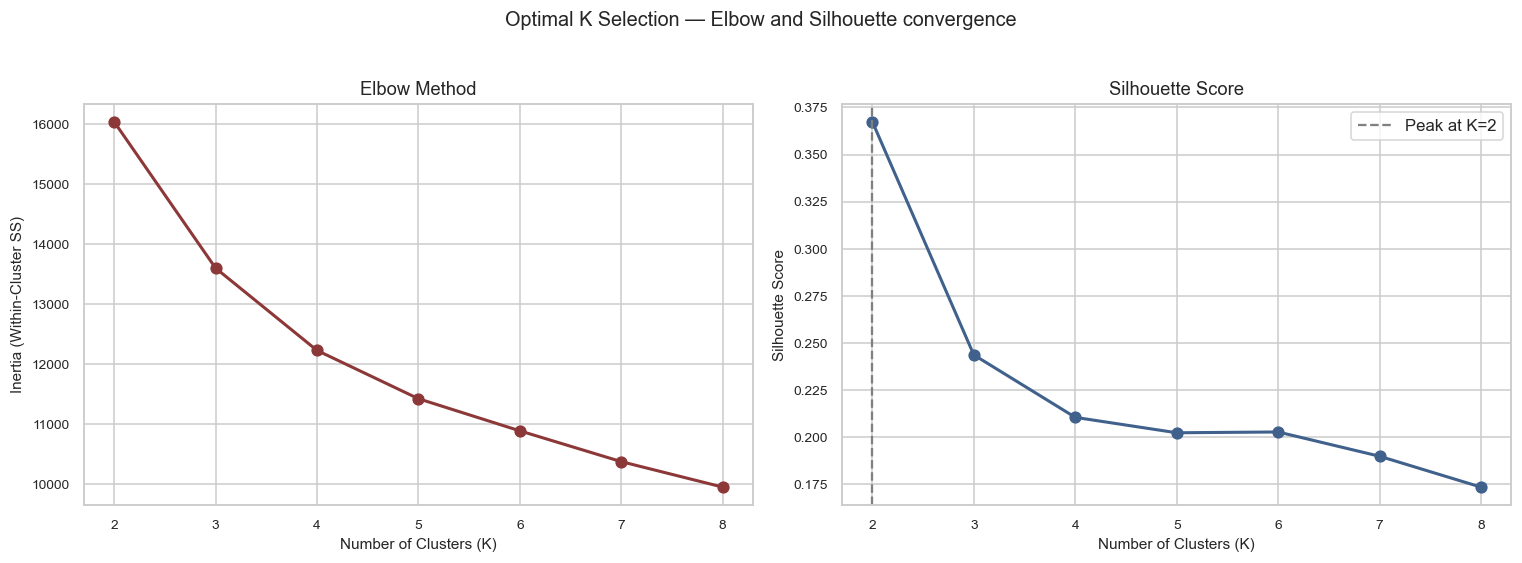


Silhouette scores by K:
  K=2: 0.3674
  K=3: 0.2437
  K=4: 0.2106
  K=5: 0.2024
  K=6: 0.2028
  K=7: 0.1900
  K=8: 0.1736


In [48]:
# Elbow Method + Silhouette Score for K = 2 to 8 
K_range   = range(2, 9)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker='o', color=(0.55, 0.22, 0.22),
             linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(list(K_range), sil_scores, marker='o', color=(0.25, 0.38, 0.55),
             linewidth=2, markersize=7)
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='gray', linestyle='--', linewidth=1.5,
                label=f'Peak at K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend()

fig.suptitle('Optimal K Selection — Elbow and Silhouette convergence',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nSilhouette scores by K:')
for k, s in zip(K_range, sil_scores):
    print(f'  K={k}: {s:.4f}')

**Decision on optimal K:** The silhouette score reaches its maximum at **K = 2** (0.367) and decreases sharply for all larger values, dropping by approximately **34%** between K = 2 and K = 3. This indicates that the strongest natural separation in the data consists of two broad customer groups. The inertia curve also shows substantial improvements up to K = 4, but with progressively diminishing returns as additional clusters are introduced.

While larger values of K would generate more granular segments, they do so at the cost of cluster cohesion and separation. Given the clear silhouette peak and the absence of a comparable improvement in interpretability at higher K values, **K = 2** was selected as the optimal solution. This choice provides the best balance between statistical quality and business relevance, yielding two clearly distinguishable customer profiles that can be translated into actionable marketing strategies.

In [49]:
# Fit final K-Means model
# K is selected based on the convergence of Elbow and Silhouette evidence above
OPTIMAL_K = best_k  

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f'Final model: K={OPTIMAL_K}')
print(f'Final Silhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print('\nCluster distribution:')
print(df['Cluster'].value_counts().sort_index())

Final model: K=2
Final Silhouette Score: 0.3674

Cluster distribution:
Cluster
0    1335
1     880
Name: count, dtype: int64


The cluster distribution provides a first interpretability check. Both clusters contain a substantial number of customers (1,335 and 880 respectively), indicating that the solution captures broad behavioural patterns rather than isolated outliers or statistically insignificant groups. From a business perspective, both clusters are large enough to support differentiated marketing actions.

The final Silhouette Score of **0.367** confirms a moderate but meaningful degree of separation between clusters. Combined with the relatively balanced cluster sizes, this suggests that the K-Means solution is identifying genuine structure in the customer base rather than artificially partitioning the data. The next step is therefore to profile the two clusters and understand which customer characteristics drive this separation.

### **4.3 Cluster Profiling**

With the cluster assignments established, each cluster is profiled across the full feature space to build an interpretable portrait. Two visualisations are used:

- A **normalised heatmap** (same format as the RFM profiling in section 3), enables immediate cross-cluster comparison on all features simultaneously
- A **scatter plot** of Income × TotalSpend coloured by cluster, anchors the clusters in the two most commercially relevant dimensions and shows how they partition the value space

In [50]:
# Cluster profile: mean of all features per cluster 
profile_cluster = (
    df.groupby('Cluster')[feature_cols + ['Age']]
    .mean().round(1)
)
print('Cluster profiles (means):')
profile_cluster

Cluster profiles (means):


,Income,TotalSpend,Recency,F,TotalChildren,Channels_Used,MntWines,MntMeatProducts,MntFruits,MntFishProducts,MntSweetProducts,MntGoldProds,Age
Cluster,,,,,,,,,,,,,
0,38693.00,181.00,48.70,10.30,1.20,3.50,100.50,36.30,6.60,9.40,6.50,21.70,45.10
1,70401.00,1233.50,49.90,21.70,0.50,4.00,608.10,355.40,55.80,79.40,57.20,77.50,47.80


The cluster means already suggest a very strong separation. The two groups differ substantially in income, spending, purchase frequency and household composition, while showing almost identical recency values. This indicates that the clustering is not capturing lifecycle stage or recent activity, but rather a deeper structural difference in customer value and consumption behaviour.

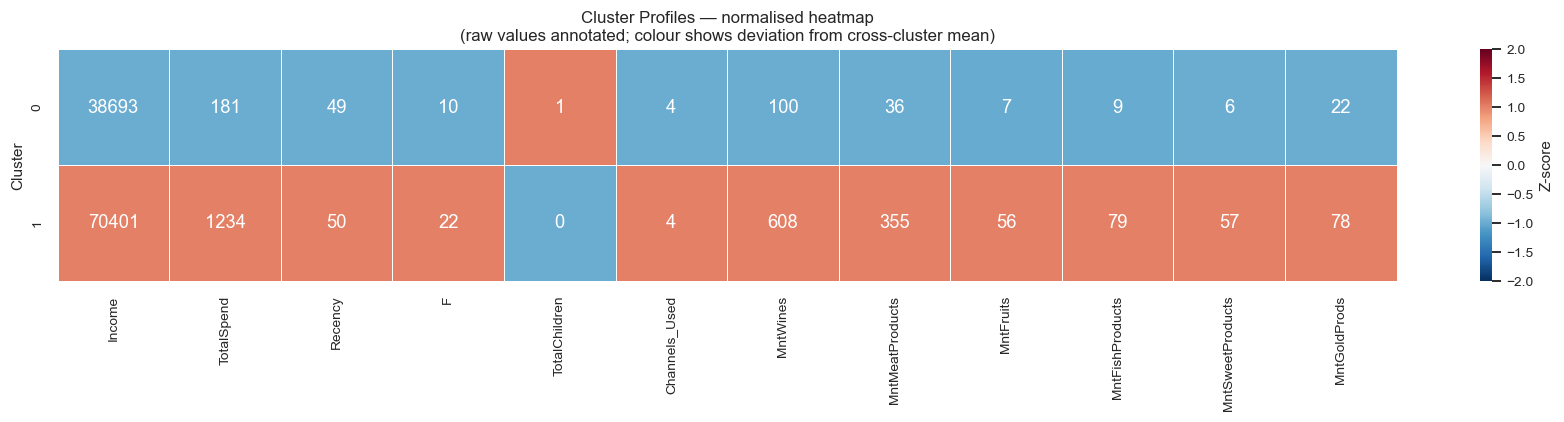

In [51]:
# Normalised heatmap
heatmap_features = feature_cols  # all 12 clustering features

profile_norm = profile_cluster[heatmap_features].apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    profile_norm,
    annot=profile_cluster[heatmap_features].round(0),
    fmt='g',
    cmap='RdBu_r', center=0, vmin=-2, vmax=2,
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-score'}
)
ax.set_title('Cluster Profiles — normalised heatmap\n'
             '(raw values annotated; colour shows deviation from cross-cluster mean)',
             fontsize=11)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

The normalised heatmap makes the separation immediately visible. Cluster 1 scores above average on almost every value-related dimension, including income, spending, purchase frequency and premium product categories, while Cluster 0 scores consistently below average. The only variable moving in the opposite direction is household size, suggesting that family structure is one of the key drivers of the partition.

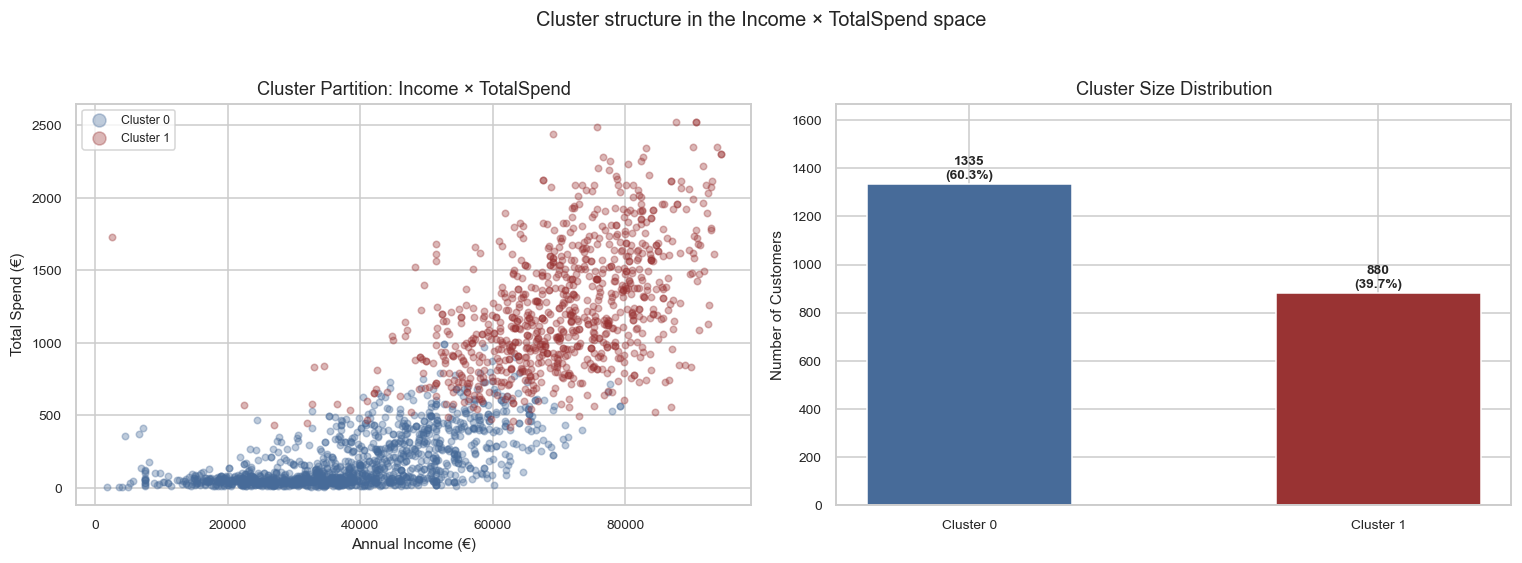

In [52]:
# Scatter: Income × TotalSpend coloured by cluster 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Income × TotalSpend
for c in sorted(df['Cluster'].unique()):
    grp = df[df['Cluster'] == c]
    axes[0].scatter(
        grp['Income'], grp['TotalSpend'],
        c=[CLUSTER_COLORS[c]], alpha=0.35, s=18,
        label=f'Cluster {c}'
    )
axes[0].set_xlabel('Annual Income (€)')
axes[0].set_ylabel('Total Spend (€)')
axes[0].set_title('Cluster Partition: Income × TotalSpend')
axes[0].legend(fontsize=8, markerscale=2)

# Bar: cluster size
cluster_sizes = df['Cluster'].value_counts().sort_index()
bars = axes[1].bar(
    [f'Cluster {c}' for c in cluster_sizes.index],
    cluster_sizes.values,
    color=[CLUSTER_COLORS[c] for c in cluster_sizes.index],
    edgecolor='white', width=0.5
)
for bar, n in zip(bars, cluster_sizes.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{n}\n({n/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_title('Cluster Size Distribution')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, cluster_sizes.max() * 1.25)

fig.suptitle('Cluster structure in the Income × TotalSpend space',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The Income × TotalSpend projection shows that the two clusters occupy distinct regions of the value space. Although some overlap exists around the boundary, the separation is largely driven by the combination of purchasing power and realised spending, confirming that the clustering captures economically meaningful differences rather than arbitrary partitions.

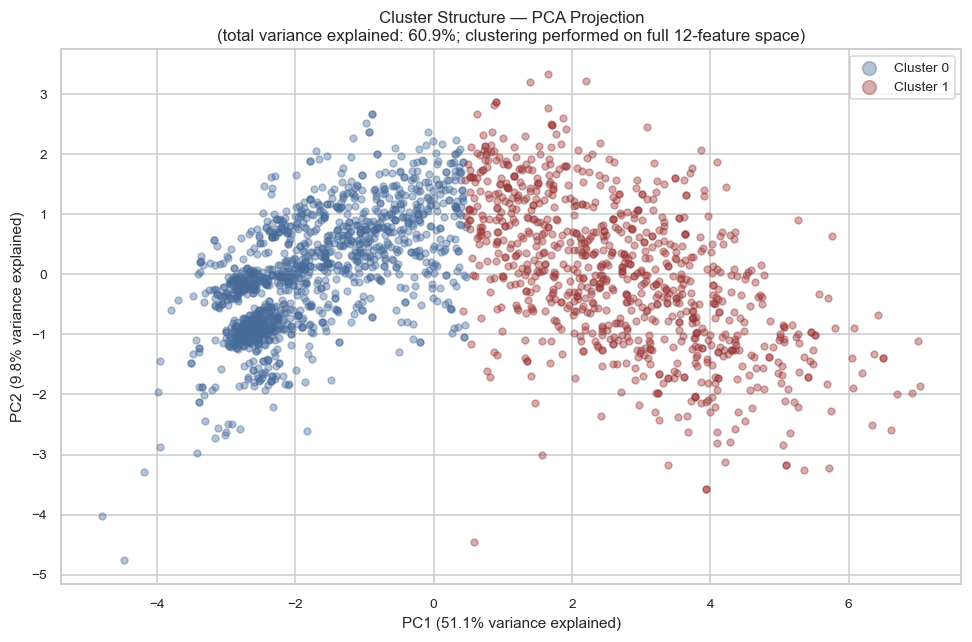

In [53]:
# PCA visualisation: 2D projection of 12-dimensional cluster space 
# PCA is used here only for visualisation, the clustering was performed on all 12 scaled features, not on the PCA components.
# This is an important methodological distinction: PCA reduces dimensionality to make the cluster structure visible; it does not change the cluster assignments.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[CLUSTER_COLORS[c]], alpha=0.4, s=20,
        label=f'Cluster {c}'
    )
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)')
ax.set_title(
    f'Cluster Structure — PCA Projection\n'
    f'(total variance explained: {sum(var_explained)*100:.1f}%; '
    f'clustering performed on full {len(feature_cols)}-feature space)',
    fontsize=11
)
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

The PCA projection provides a multidimensional validation of the clustering result. Even after reducing the original 12-feature space to two principal components explaining approximately 61% of total variance, the two clusters remain clearly separated. This indicates that the segmentation is not driven by a single variable but reflects a broader pattern across the feature set.

In [54]:
# Cluster labels derived from manual inspection of the normalised heatmap (Section 4.3).
# With K=2, the two clusters separate cleanly along two axes:
#   - Income and TotalSpend (Cluster 1 >> Cluster 0)
#   - TotalChildren (Cluster 0 >> Cluster 1)
# The product category breakdown confirms the behavioral logic:
#   Cluster 1 concentrates spend in Wines and Meat (premium, adult-oriented);
#   Cluster 0 shows uniformly low category spend consistent with constrained budgets.

cluster_label_map = {
    0: 'Family-Oriented Budget Buyer',
    1: 'High-Income Childless Spender',
}

df['Cluster_Label'] = df['Cluster'].map(cluster_label_map)

print('Cluster label assignments:')
for c, lbl in cluster_label_map.items():
    n     = (df['Cluster'] == c).sum()
    spend = df[df['Cluster'] == c]['TotalSpend'].mean()
    inc   = df[df['Cluster'] == c]['Income'].mean()
    print(f'  Cluster {c} → "{lbl}"  (n={n}, avg income=€{inc:.0f}, avg spend=€{spend:.0f})')

Cluster label assignments:
  Cluster 0 → "Family-Oriented Budget Buyer"  (n=1335, avg income=€38693, avg spend=€181)
  Cluster 1 → "High-Income Childless Spender"  (n=880, avg income=€70401, avg spend=€1233)


**Cluster 0: Family-Oriented Budget Buyer.**  Lower income (avg. €38,693), minimal discretionary spend (avg. €181), one or more children at home. Spending is spread thinly across all categories with no dominant preference. Channel behaviour skews toward Deals, consistent with price sensitivity driven by household budget constraints.

**Cluster 1: High-Income Childless Spender.**  Higher income (avg. €70,401), high total spend (avg. €1,234), no children. Strongly concentrated in Wines (€608) and Meat Products (€355); premium, adult-oriented categories with higher margins. Omnichannel engagement (avg. 4 channels used). This cluster maps closely onto the Champions and Sleeping Giants RFM segments, confirming that premium spend is structurally driven by household  composition and income rather than by engagement frequency alone.

### **4.4 RFM Segments vs. Clusters. Overlap Analysis**

The central analytical question of this task is: *do the K-Means clusters reproduce the RFM segmentation, or do they reveal additional structure?*

The comparison is performed through a **crosstab** of RFM Segment × Cluster, normalised by row. Each cell shows what proportion of customers in a given RFM segment end up in each cluster. If a segment concentrates strongly in a single cluster (one cell close to 1.0), the two methods agree about that group. If a segment distributes across multiple clusters, the clustering has detected internal heterogeneity that the RFM rules treat as homogeneous.

In [55]:
# Ensure updated RFM Segment column is present
df['Segment'] = df.apply(assign_segment, axis=1)

# Ensure Cluster column is present
if 'Cluster' not in df.columns:
    km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
    df['Cluster'] = km_final.fit_predict(X_scaled)

display(
    pd.crosstab(
        df['Segment'],
        df['Cluster'],
        margins=True
    )
)

Cluster,0,1,All
Segment,,,
At Risk / Lost,175,0,175
Champions,21,408,429
Loyal Mid-Spenders,408,36,444
New / Occasional Buyer,279,0,279
Other,21,90,111
Price-Sensitive,412,0,412
Sleeping Giants,19,346,365
All,1335,880,2215


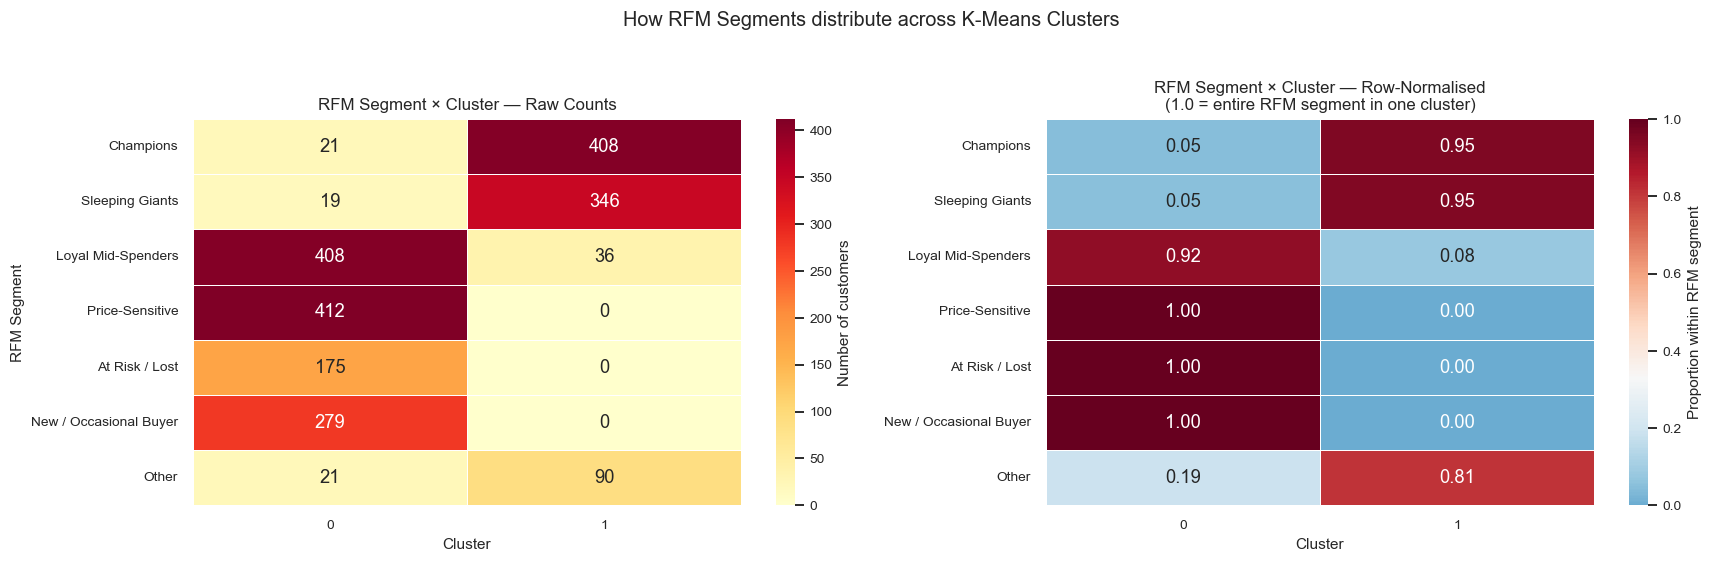

In [56]:
# Crosstab: RFM Segment × Cluster (row-normalised) 
rfm_order = [
    'Champions',
    'Sleeping Giants',
    'Loyal Mid-Spenders',
    'Price-Sensitive',
    'At Risk / Lost',
    'New / Occasional Buyer',
    'Other'
]

ct_raw = pd.crosstab(df['Segment'], df['Cluster'])
ct_raw = ct_raw.reindex([s for s in rfm_order if s in ct_raw.index])
ct_norm = ct_raw.div(ct_raw.sum(axis=1), axis=0).round(3)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw counts
sns.heatmap(
    ct_raw, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=axes[0],
    cbar_kws={'label': 'Number of customers'}
)
axes[0].set_title('RFM Segment × Cluster — Raw Counts', fontsize=11)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('RFM Segment')

# Right: row-normalised proportions
sns.heatmap(
    ct_norm, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0.33, vmin=0, vmax=1,
    linewidths=0.5, linecolor='white', ax=axes[1],
    cbar_kws={'label': 'Proportion within RFM segment'}
)
axes[1].set_title('RFM Segment × Cluster — Row-Normalised\n'
                  '(1.0 = entire RFM segment in one cluster)', fontsize=11)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('')

fig.suptitle('How RFM Segments distribute across K-Means Clusters',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The overlap between the two segmentation approaches is remarkably strong. Champions and Sleeping Giants are concentrated almost entirely in Cluster 1 (95%), while Price-Sensitive, At Risk / Lost, and New / Occasional Buyers are assigned exclusively to Cluster 0. Loyal Mid-Spenders also show a very strong concentration in Cluster 0 (92%).

This result indicates that the unsupervised clustering is not discovering a completely different customer structure. Instead, it independently recovers the same underlying separation already suggested by the RFM analysis: a distinction between high-income, high-spending customers and lower-value, budget-oriented customers.

The main contribution of K-Means therefore lies not in redefining customer value tiers, but in enriching them. While RFM focuses on behavioural engagement (recency, frequency, and monetary value), clustering reveals the demographic and product-preference characteristics associated with those behaviours. The two approaches should therefore be viewed as complementary rather than competing segmentation frameworks.

### **4.5 What Does Clustering Reveal That RFM Cannot?**

This is the central analytical question of section 4. The answer requires looking not just at where the two segmentations agree, but at where they structurally diverge and why.

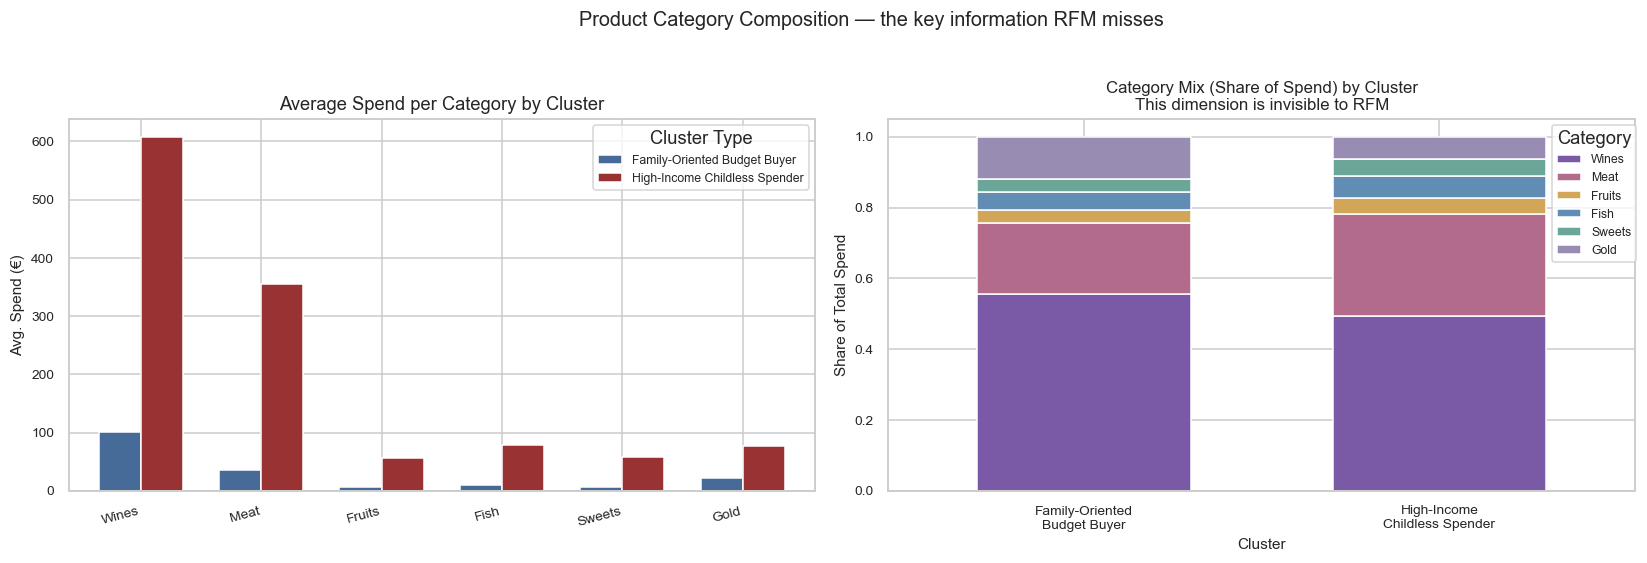


Category share by cluster:


,Wines,Meat,Fruits,Fish,Sweets,Gold
Cluster,,,,,,
0,0.56,0.20,0.04,0.05,0.04,0.12
1,0.49,0.29,0.04,0.06,0.05,0.06


In [57]:
# Product category composition per cluster 
# This is the dimension RFM cannot see: what customers buy, not just how much.

plt.close('all')

CLUSTER_NAMES = {
    0: 'Family-Oriented\nBudget Buyer',
    1: 'High-Income\nChildless Spender'
}

category_cols = [
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

category_labels = ['Wines', 'Meat', 'Fruits', 'Fish', 'Sweets', 'Gold']

# Average spend per category by cluster
cat_profile = df.groupby('Cluster')[category_cols].mean()
cat_profile.columns = category_labels

# Share of spend per category within each cluster
cat_share = cat_profile.div(cat_profile.sum(axis=1), axis=0).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute spend per category
cat_profile.T.plot(
    kind='bar',
    ax=axes[0],
    color=[CLUSTER_COLORS[c] for c in cat_profile.index],
    edgecolor='white',
    width=0.7
)

axes[0].set_title('Average Spend per Category by Cluster')
axes[0].set_ylabel('Avg. Spend (€)')
axes[0].set_xticklabels(category_labels, rotation=15, ha='right')
axes[0].legend(
    [CLUSTER_NAMES[c].replace('\n', ' ') for c in cat_profile.index],
    title='Cluster Type',
    fontsize=8
)

# Category share within each cluster
cat_share.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=CATEGORY_COLORS,
    edgecolor='white',
    width=0.6
)

axes[1].set_title(
    'Category Mix (Share of Spend) by Cluster\n'
    'This dimension is invisible to RFM',
    fontsize=11
)
axes[1].set_ylabel('Share of Total Spend')
axes[1].set_xticklabels(
    [CLUSTER_NAMES[c] for c in cat_share.index],
    rotation=0
)
axes[1].legend(
    title='Category',
    fontsize=8,
    bbox_to_anchor=(1.01, 1)
)

fig.suptitle(
    'Product Category Composition — the key information RFM misses',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()

print('\nCategory share by cluster:')
display(cat_share.round(2))

The category composition charts highlight the main information that RFM cannot explicitly capture: what customers buy. While the two clusters differ strongly in overall value, they also exhibit distinct spending compositions. The High-Income Childless Spender cluster allocates a larger share of expenditure to Meat Products and premium categories, whereas the Family-Oriented Budget Buyer cluster is relatively more concentrated on Wines and Gold Products. These differences are invisible to RFM, which summarizes customers through aggregate spending alone. Clustering therefore complements RFM by revealing product preferences that can inform more targeted communication and merchandising strategies.

In [58]:
# Distribution of Sleeping Giants across clusters
sg = df[df['Segment'] == 'Sleeping Giants']

if len(sg) > 0:
    sg_cluster_dist = sg['Cluster'].value_counts().sort_index()
    print('Sleeping Giants distribution across clusters:')
    print(sg_cluster_dist)
    print(f'\nTotal Sleeping Giants: {len(sg)}')
    print(f'Spread across {sg["Cluster"].nunique()} cluster(s)')

Sleeping Giants distribution across clusters:
Cluster
0     19
1    346
Name: count, dtype: int64

Total Sleeping Giants: 365
Spread across 2 cluster(s)


The overlap between the two approaches is remarkably strong. Approximately 95% of Sleeping Giants belong to Cluster 1 (High-Income Childless Spender), indicating that the RFM rule identifying high-value but disengaged customers is largely recovered by the unsupervised clustering procedure. This convergence strengthens confidence in the segment: Sleeping Giants are not an artifact of arbitrary thresholds but a genuinely distinct customer group present in the data.

From a strategic perspective, the result suggests that most Sleeping Giants share a similar socioeconomic and purchasing profile. Reactivation efforts can therefore be designed around a common value proposition, centered on premium product categories such as Wines and Meat Products, rather than relying on broad discount-based campaigns. Unlike other segments, where clustering may reveal meaningful internal variation, Sleeping Giants appear comparatively homogeneous across both analytical frameworks.

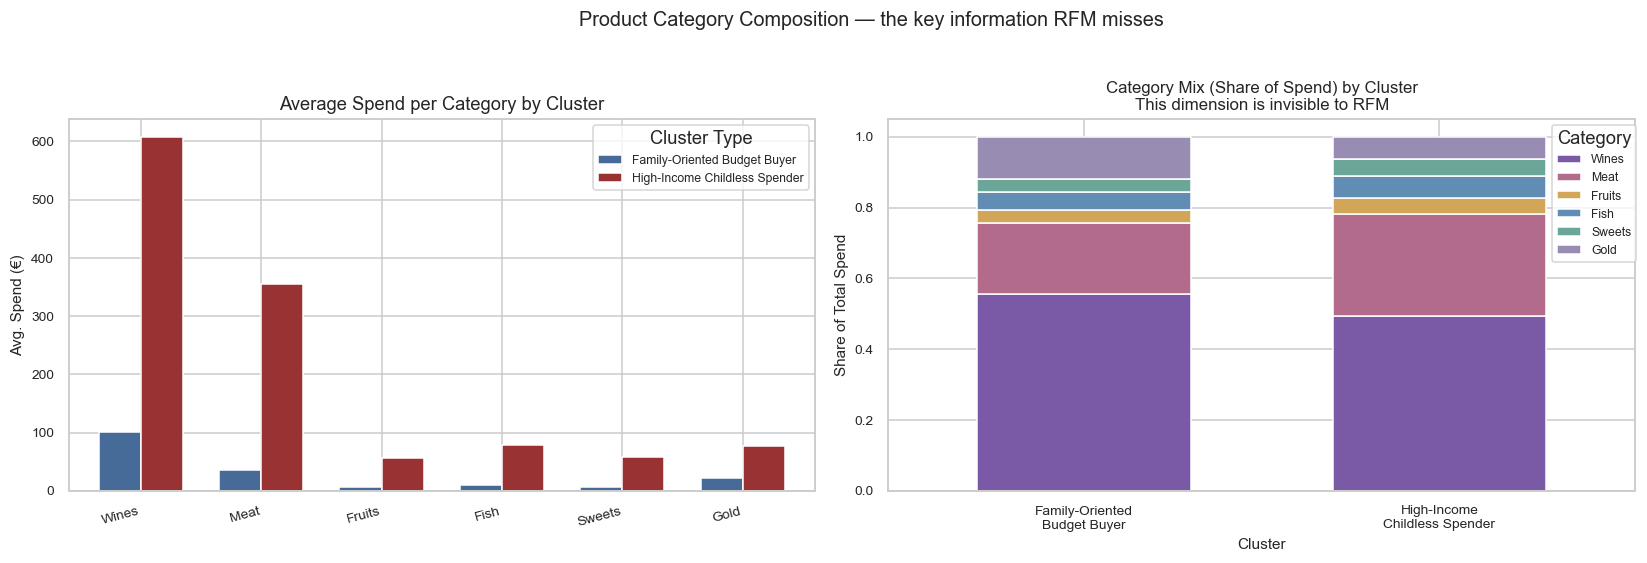


Category share by cluster:


,Wines,Meat,Fruits,Fish,Sweets,Gold
Cluster,,,,,,
0,0.56,0.20,0.04,0.05,0.04,0.12
1,0.49,0.29,0.04,0.06,0.05,0.06


In [59]:
# Product category composition per cluster 
# This is the dimension RFM cannot see: what customers buy, not just how much.

plt.close('all')

CLUSTER_NAMES = {
    0: 'Family-Oriented\nBudget Buyer',
    1: 'High-Income\nChildless Spender'
}

category_cols = [
    'MntWines', 'MntMeatProducts', 'MntFruits',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

category_labels = ['Wines', 'Meat', 'Fruits', 'Fish', 'Sweets', 'Gold']

# Average spend per category by cluster
cat_profile = df.groupby('Cluster')[category_cols].mean()
cat_profile.columns = category_labels

# Share of spend per category within each cluster
cat_share = cat_profile.div(cat_profile.sum(axis=1), axis=0).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute spend per category
cat_profile.T.plot(
    kind='bar',
    ax=axes[0],
    color=[CLUSTER_COLORS[c] for c in cat_profile.index],
    edgecolor='white',
    width=0.7
)

axes[0].set_title('Average Spend per Category by Cluster')
axes[0].set_ylabel('Avg. Spend (€)')
axes[0].set_xticklabels(category_labels, rotation=15, ha='right')
axes[0].legend(
    [CLUSTER_NAMES[c].replace('\n', ' ') for c in cat_profile.index],
    title='Cluster Type',
    fontsize=8
)

# Category share within each cluster
cat_share.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=CATEGORY_COLORS,
    edgecolor='white',
    width=0.6
)

axes[1].set_title(
    'Category Mix (Share of Spend) by Cluster\n'
    'This dimension is invisible to RFM',
    fontsize=11
)
axes[1].set_ylabel('Share of Total Spend')
axes[1].set_xticklabels(
    [CLUSTER_NAMES[c] for c in cat_share.index],
    rotation=0
)
axes[1].legend(
    title='Category',
    fontsize=8,
    bbox_to_anchor=(1.01, 1)
)

fig.suptitle(
    'Product Category Composition — the key information RFM misses',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()

print('\nCategory share by cluster:')
display(cat_share.round(2))

### **4.6 Task D Summary — RFM vs. Clustering: Complementary, Not Competing**

In [60]:
summary = pd.DataFrame([
    {
        'Dimension': 'Segmentation logic',
        'RFM': 'Rule-based thresholds',
        'K-Means': 'Data-driven clustering'
    },
    {
        'Dimension': 'Variables used',
        'RFM': 'R, F, M (3 features)',
        'K-Means': '12 behavioural & product features'
    },
    {
        'Dimension': 'Temporal awareness',
        'RFM': 'Core dimension',
        'K-Means': 'One feature among many'
    },
    {
        'Dimension': 'Product affinity',
        'RFM': 'Not captured',
        'K-Means': 'Explicitly captured'
    },
    {
        'Dimension': 'Interpretability',
        'RFM': 'High',
        'K-Means': 'Requires profiling'
    },
    {
        'Dimension': 'Main strength',
        'RFM': 'Lifecycle positioning',
        'K-Means': 'Customer archetypes'
    },
    {
        'Dimension': 'Best use case',
        'RFM': 'Timing & prioritisation',
        'K-Means': 'Content & product targeting'
    }
])

display(
    summary
    .style
    .hide(axis='index')
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal'
    })
    .set_table_styles([
        {'selector': 'th',
         'props': [('text-align', 'left'),
                   ('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('max-width', '220px')]}
    ])
)

Dimension,RFM,K-Means
Segmentation logic,Rule-based thresholds,Data-driven clustering
Variables used,"R, F, M (3 features)",12 behavioural & product features
Temporal awareness,Core dimension,One feature among many
Product affinity,Not captured,Explicitly captured
Interpretability,High,Requires profiling
Main strength,Lifecycle positioning,Customer archetypes
Best use case,Timing & prioritisation,Content & product targeting


The comparison highlights the complementary nature of the two approaches. RFM focuses on customer lifecycle and engagement, identifying who is active, disengaging, or at risk. K-Means, by contrast, incorporates demographic, behavioural and product-level information, revealing broader customer archetypes that cannot be captured through Recency, Frequency and Monetary value alone.

The strongest point of convergence concerns the Sleeping Giants segment: approximately 95% of these customers belong to the High-Income Childless Spender cluster. This agreement validates both the RFM definition and the associated reactivation strategy, suggesting that Sleeping Giants form a genuinely coherent customer group rather than an artifact of rule-based thresholds.

For other segments, particularly Loyal Mid-Spenders and the residual categories, the cluster assignment is more varied. This indicates that customers with similar RFM scores may still differ substantially in income, household composition, purchasing intensity and product preferences. Clustering therefore complements RFM not by replacing it, but by adding a deeper customer profile that supports more tailored communication and targeting decisions.

## 5. Communication Strategy

Every analytical decision made in this project, from the cleaning choices in section 1 to the cluster profiles in section 4, was made in service of a single operational objective: identifying who the customers are so that the right message can reach the right person through the right channel.

This section translates the segmentation findings into a concrete, differentiated communication strategy. The five RFM segments from Task C serve as the primary targeting framework, enriched by the product affinity profiles uncovered in section 4. For each segment, three dimensions are specified:

- **Channel:** where to reach them, grounded in the channel preference analysis of Section 2.2
- **Message tone:** how to communicate, derived from the behavioral and demographic profile of each segment
- **Content direction:** what to say, informed by product category composition from the cluster analysis

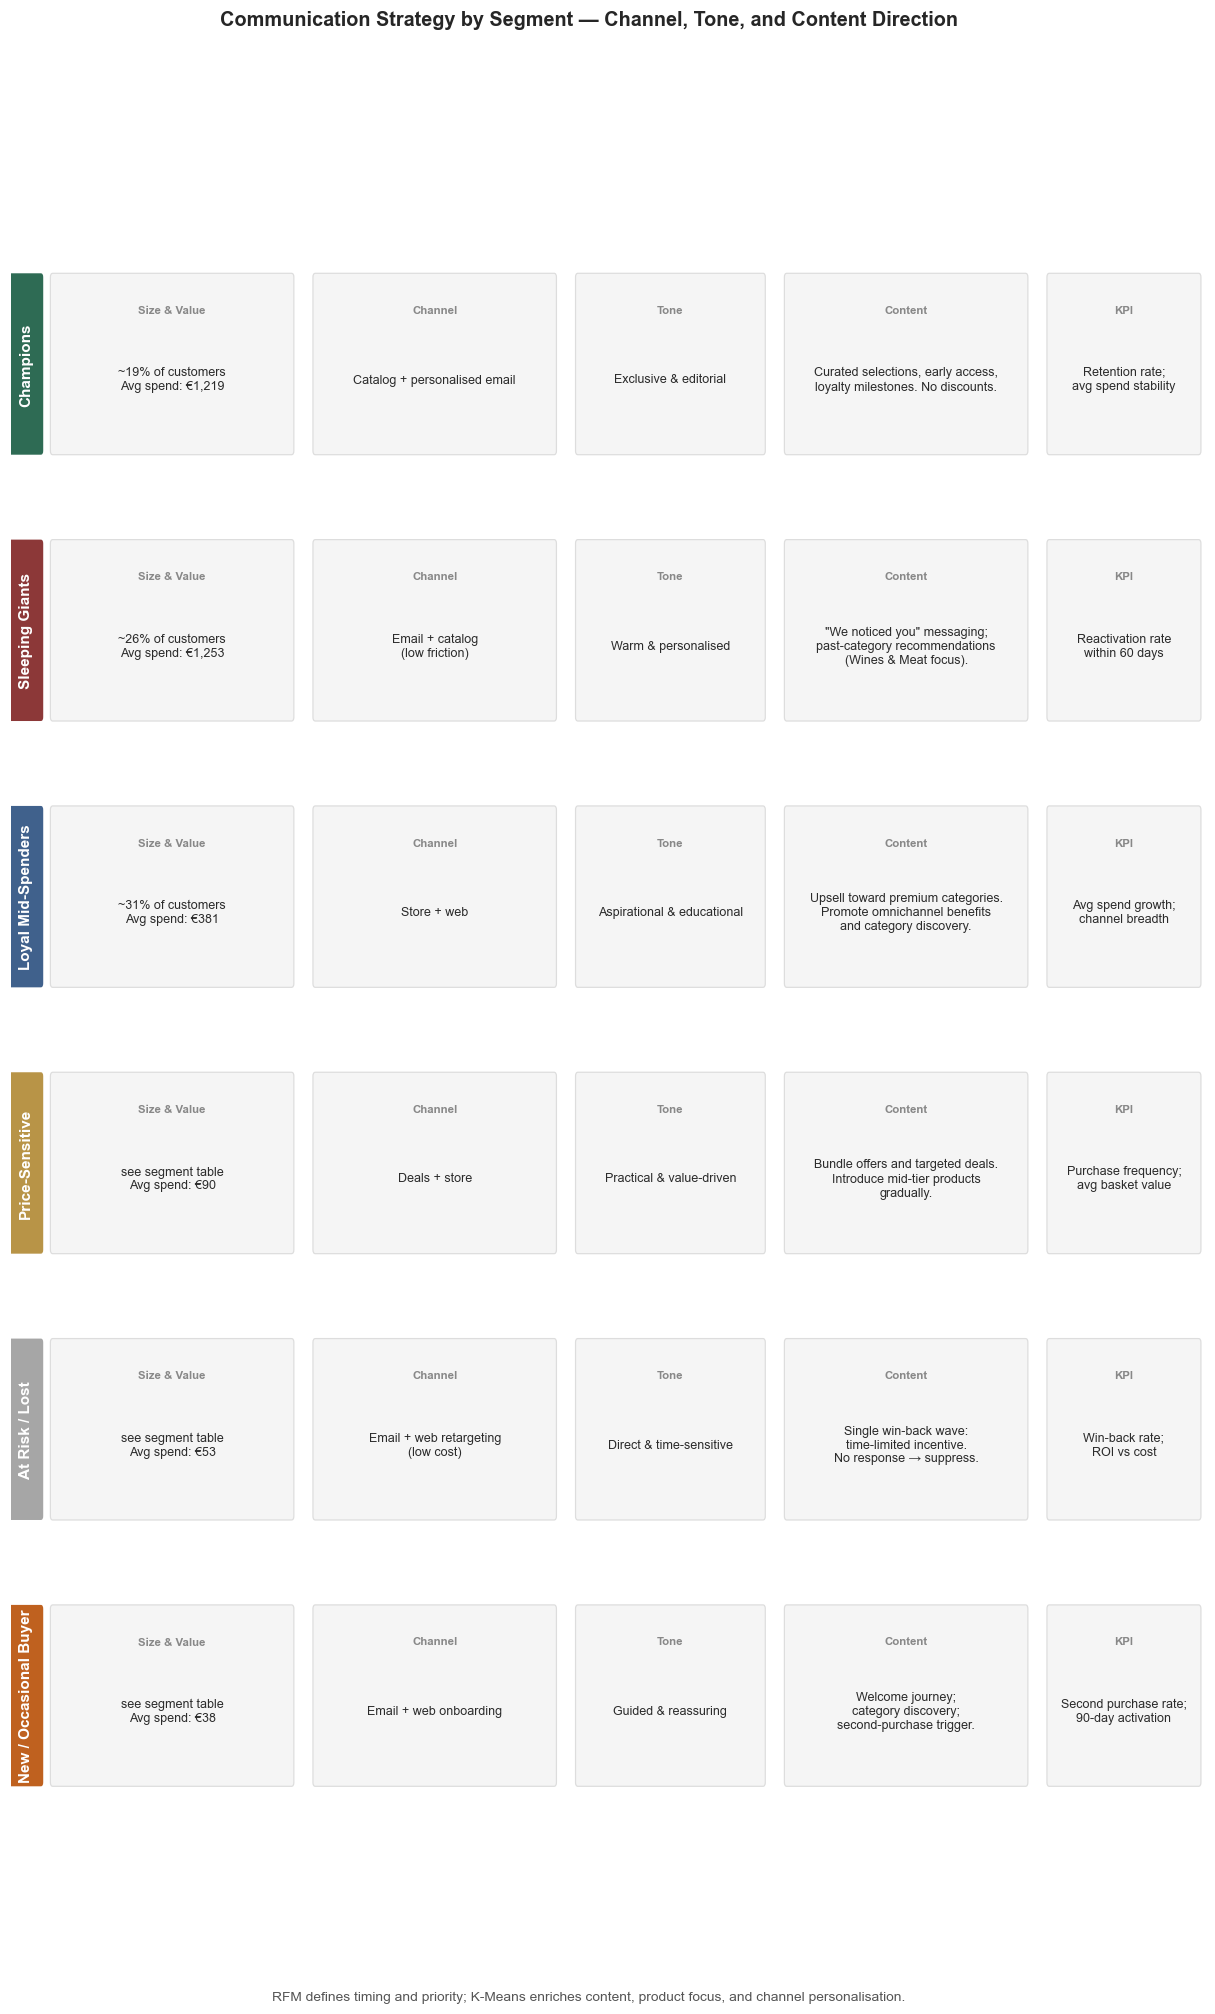

Strategy overview saved.


In [61]:
# Communication Strategy: visual summary

strategy_data = [
    {
        'Segment'    : 'Champions',
        'Size'       : '~19% of customers',
        'Avg Spend'  : '€1,219',
        'Channel'    : 'Catalog + personalised email',
        'Tone'       : 'Exclusive & editorial',
        'Content'    : 'Curated selections, early access,\nloyalty milestones. No discounts.',
        'KPI'        : 'Retention rate;\navg spend stability',
        'Color'      : (0.18, 0.42, 0.33)
    },
    {
        'Segment'    : 'Sleeping Giants',
        'Size'       : '~26% of customers',
        'Avg Spend'  : '€1,253',
        'Channel'    : 'Email + catalog\n(low friction)',
        'Tone'       : 'Warm & personalised',
        'Content'    : '"We noticed you" messaging;\npast-category recommendations\n(Wines & Meat focus).',
        'KPI'        : 'Reactivation rate\nwithin 60 days',
        'Color'      : (0.55, 0.22, 0.22)
    },
    {
        'Segment'    : 'Loyal Mid-Spenders',
        'Size'       : '~31% of customers',
        'Avg Spend'  : '€381',
        'Channel'    : 'Store + web',
        'Tone'       : 'Aspirational & educational',
        'Content'    : 'Upsell toward premium categories.\nPromote omnichannel benefits\nand category discovery.',
        'KPI'        : 'Avg spend growth;\nchannel breadth',
        'Color'      : (0.25, 0.38, 0.55)
    },
    {
        'Segment'    : 'Price-Sensitive',
        'Size'       : 'see segment table',
        'Avg Spend'  : '€90',
        'Channel'    : 'Deals + store',
        'Tone'       : 'Practical & value-driven',
        'Content'    : 'Bundle offers and targeted deals.\nIntroduce mid-tier products\ngradually.',
        'KPI'        : 'Purchase frequency;\navg basket value',
        'Color'      : (0.72, 0.58, 0.28)
    },
    {
        'Segment'    : 'At Risk / Lost',
        'Size'       : 'see segment table',
        'Avg Spend'  : '€53',
        'Channel'    : 'Email + web retargeting\n(low cost)',
        'Tone'       : 'Direct & time-sensitive',
        'Content'    : 'Single win-back wave:\ntime-limited incentive.\nNo response → suppress.',
        'KPI'        : 'Win-back rate;\nROI vs cost',
        'Color'      : (0.65, 0.65, 0.65)
    },
    {
        'Segment'    : 'New / Occasional Buyer',
        'Size'       : 'see segment table',
        'Avg Spend'  : '€38',
        'Channel'    : 'Email + web onboarding',
        'Tone'       : 'Guided & reassuring',
        'Content'    : 'Welcome journey;\ncategory discovery;\nsecond-purchase trigger.',
        'KPI'        : 'Second purchase rate;\n90-day activation',
        'Color'      : (0.75, 0.38, 0.12)
    }
]

fig, axes = plt.subplots(len(strategy_data), 1, figsize=(14, 18))
fig.subplots_adjust(hspace=0.38)

for ax, seg in zip(axes, strategy_data):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Coloured left bar
    ax.add_patch(mpatches.FancyBboxPatch(
        (0, 0.05), 0.25, 0.9,
        boxstyle='round,pad=0.02',
        facecolor=seg['Color'], edgecolor='none'
    ))
    ax.text(
        0.125, 0.5, seg['Segment'],
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color='white', rotation=90
    )

    # Info boxes
    boxes = [
        (0.35, 'Size & Value',  f"{seg['Size']}\nAvg spend: {seg['Avg Spend']}"),
        (2.55, 'Channel',       seg['Channel']),
        (4.75, 'Tone',          seg['Tone']),
        (6.50, 'Content',       seg['Content']),
        (8.70, 'KPI',           seg['KPI']),
    ]
    widths = [2.0, 2.0, 1.55, 2.0, 1.25]

    for (x, label, text), w in zip(boxes, widths):
        ax.add_patch(mpatches.FancyBboxPatch(
            (x, 0.05), w, 0.9,
            boxstyle='round,pad=0.02',
            facecolor='#f5f5f5',
            edgecolor='#dddddd',
            linewidth=0.8
        ))
        ax.text(
            x + w/2, 0.78, label,
            ha='center', va='center',
            fontsize=7.5,
            color='#888888',
            fontweight='bold'
        )
        ax.text(
            x + w/2, 0.42, text,
            ha='center', va='center',
            fontsize=8.2,
            color='#2b2b2b',
            multialignment='center'
        )

fig.suptitle(
    'Communication Strategy by Segment — Channel, Tone, and Content Direction',
    fontsize=13,
    y=1.01,
    fontweight='bold'
)

fig.text(
    0.5, 0.005,
    'RFM defines timing and priority; K-Means enriches content, product focus, and channel personalisation.',
    ha='center',
    fontsize=9,
    color='#555555'
)

plt.savefig('communication_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strategy overview saved.')

### **5.1 Enriching the Strategy with Cluster Insights**

The RFM segments provide the *when* and *how urgently* of communication. The K-Means clusters from Section 4 add the *what*: the customer profile, product category affinity, and channel context that RFM cannot fully capture.

The cluster analysis shows that approximately 95% of Sleeping Giants belong to Cluster 1 (*High-Income Childless Spender*), with spending concentrated in Wines and Meat. This means that a common product-specific reactivation message is appropriate for most customers in this segment:

> *"Your favourite selections are waiting. Here's what's new in our curated wine and premium food range."*

The product focus is not a guess: it is derived from the category composition of Cluster 1. This is a concrete example of what clustering adds to RFM: not a replacement segmentation, but a content specification that the three-dimensional rule system cannot produce on its own.

For **Champions**, the cluster profile confirms high income, low household constraints, high spending, and strong omnichannel engagement. Their communication should therefore be sophisticated, product-rich, and non-promotional. The tone is that of a brand addressing a loyal connoisseur, not a customer being pushed a discount.

For **Loyal Mid-Spenders**, the cluster assignment is more mixed, indicating internal heterogeneity that RFM treats as homogeneous. Customers closer to Cluster 1 can receive aspirational upselling toward premium categories such as Wines and Meat. Customers closer to Cluster 0 require a softer, value-led progression before premium positioning is introduced.

In [62]:
# Channel × Segment strategic matrix 
# Channel × Segment strategic matrix

channel_matrix = pd.DataFrame({
    'Segment': [
        'Champions',
        'Sleeping Giants',
        'Loyal Mid-Spenders',
        'Price-Sensitive',
        'At Risk / Lost',
        'New / Occasional Buyer'
    ],
    'Primary Channel': [
        'Catalog + Email',
        'Email + Catalog',
        'Store + Web',
        'Deals + Store',
        'Email + Retargeting',
        'Email + Web Onboarding'
    ],
    'Message Tone': [
        'Exclusive & editorial',
        'Warm & personalised',
        'Aspirational & educational',
        'Practical & value-driven',
        'Clear & cost-conscious',
        'Guided & reassuring'
    ],
    'Avoid': [
        'Discounts or mass promotions',
        'Generic newsletters; price-based triggers',
        'Discount-led messaging that commoditises quality',
        'Premium positioning before trust is built',
        'High-cost channels; repeated contact with no response',
        'Overly aggressive selling before habits form'
    ],
    'Timing': [
        'Ongoing loyalty maintenance',
        'Within 30–60 days after recency decline',
        'Quarterly, aligned with repurchase cycle',
        'Promotion-triggered or deal-driven',
        'Single win-back wave; then suppress',
        'Immediately after first purchase'
    ]
})

display(
    channel_matrix
    .set_index('Segment')
    .style
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal'
    })
    .set_table_styles([
        {'selector': 'th',
         'props': [('text-align', 'left'),
                   ('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('max-width', '260px')]}
    ])
)

,Primary Channel,Message Tone,Avoid,Timing
Segment,,,,
Champions,Catalog + Email,Exclusive & editorial,Discounts or mass promotions,Ongoing loyalty maintenance
Sleeping Giants,Email + Catalog,Warm & personalised,Generic newsletters; price-based triggers,Within 30–60 days after recency decline
Loyal Mid-Spenders,Store + Web,Aspirational & educational,Discount-led messaging that commoditises quality,"Quarterly, aligned with repurchase cycle"
Price-Sensitive,Deals + Store,Practical & value-driven,Premium positioning before trust is built,Promotion-triggered or deal-driven
At Risk / Lost,Email + Retargeting,Clear & cost-conscious,High-cost channels; repeated contact with no response,Single win-back wave; then suppress
New / Occasional Buyer,Email + Web Onboarding,Guided & reassuring,Overly aggressive selling before habits form,Immediately after first purchase


### **5.2 Strategic Priorities**

Not all segments warrant equal investment. The communication budget should be allocated in proportion to the expected return, which is a function of segment size, average spend, and reactivation probability.

**Tier 1 – Protect and Retain: Champions.**

Champions represent the most valuable active customers in the database. Their high spending, frequent purchasing behaviour, and strong engagement indicate that the primary objective is retention rather than short-term sales stimulation. Communication should focus on loyalty recognition, exclusive access, curated recommendations, and premium customer experiences. Budget allocation can be relatively high on a per-customer basis, as preserving these relationships protects a disproportionate share of customer value.

**Tier 2 – Reactivate: Sleeping Giants.**

Sleeping Giants represent one of the most attractive opportunities identified in the analysis. Despite their low recent engagement, they display spending levels comparable to Champions, suggesting substantial recoverable value. On average, each customer in this segment has historically generated approximately €1,253 in spend. Cluster analysis further indicates a strong preference for premium categories such as Wines and Meat Products, providing a clear direction for personalised reactivation campaigns. Budget allocation should focus on targeted interventions with measurable outcomes, such as purchases within 60 days of campaign exposure.

**Tier 3 – Grow: Loyal Mid-Spenders.**

Loyal Mid-Spenders form the largest segment in the customer base and represent the most natural growth opportunity. While their current spending levels are substantially lower than those of Champions and Sleeping Giants, their purchasing frequency indicates an established relationship with the brand. Increasing average spend through premium category recommendations, cross-selling initiatives, and broader channel adoption could generate meaningful aggregate revenue gains. Budget allocation should prioritise scalable, content-driven campaigns rather than expensive one-to-one interventions.

**Tier 4 – Maintain Efficiency: Price-Sensitive, At Risk / Lost, and New / Occasional Buyers.**

These segments generate comparatively low spending and therefore require cost-efficient communication strategies. Price-Sensitive customers should be approached through promotions, bundles, and value-oriented offers. At Risk / Lost customers should receive a limited win-back effort before communication frequency is reduced to avoid inefficient spending. New / Occasional Buyers require onboarding and second-purchase activation campaigns designed to convert recent purchasers into repeat customers. Budget allocation should remain relatively low and rely heavily on automated communication channels.

### **5.3 Keeping the Segmentation Current**

The RFM segments and cluster profiles developed in this analysis represent customer behaviour at a specific point in time. Customer preferences, purchasing patterns, and product offerings evolve continuously, making segmentation a dynamic rather than permanent asset.

Several conditions may justify a segmentation refresh: significant changes in customer retention behaviour, major modifications to the product portfolio or sales channels, or simply the passage of time. As a practical guideline, a full reassessment every six months would help ensure that the segments remain representative of the underlying customer base.

The RFM framework is particularly sensitive to shifts in customer distributions because its scoring system relies on quintile boundaries. If spending or purchasing behaviour changes substantially across the customer base, the thresholds used to define high- and low-value customers should be recalibrated using updated data.

The cluster solution requires additional monitoring. Because K-Means derives its structure directly from the observed data, changes in customer behaviour may alter the characteristics of the resulting clusters. Re-running the algorithm is therefore not sufficient on its own; the resulting profiles must also be interpreted and validated. If future clustering runs produce substantially lower silhouette scores or increasingly fragmented cluster profiles, alternative values of K should be re-evaluated.

## 6. Conclusion
This analysis transformed raw customer records into an actionable segmentation framework through four stages: data cleaning and feature engineering, exploratory analysis, RFM segmentation, and unsupervised clustering.

The results show that customer value is highly concentrated and that meaningful differences exist not only in spending levels but also in purchasing behaviour, household characteristics, and product preferences. Champions and Sleeping Giants together represent less than half of the customer base, yet exhibit by far the highest average spending levels, making them the segments with the greatest commercial importance.

The RFM framework proved effective at identifying customer lifecycle position by combining recency, frequency, and monetary value into an interpretable segmentation. The clustering analysis complemented this view by incorporating additional behavioural, demographic, and product-level information. In particular, product category preferences emerged as a dimension that is largely invisible to RFM but highly relevant for communication design and product targeting.

The results suggest that retention and reactivation initiatives may offer a more immediate source of value than broad acquisition efforts, particularly given the concentration of spending among existing high-value customers. At the same time, the analysis highlights the importance of tailoring communication not only to customer value, but also to the specific products and categories that customers prefer.

Several extensions could further strengthen this framework. First, a predictive churn model could be developed to identify customers at risk of becoming inactive before disengagement occurs. Second, tracking how customers move across RFM segments and how their cluster membership evolves over time would transform the current snapshot into a dynamic customer monitoring system. Such extensions would build directly on the foundation established in this work: clean data, interpretable features, and customer segments that are both statistically meaningful and commercially actionable.